# Study 2 Serum — Comprehensive Analysis
## B2A Experiment: Multi-Step Agent Shopping Behavior

**Baseline: `vague` funnel** (no specific keywords → maximum agent freedom)

- Part I (§1–11): Core analysis using `vague` baseline
- Part II (§12–14): Agency (funnel) effect
- Part III (§15–17): Statistical rigor & summary

### Data
- `s2`: Study 2 serum, vague only (multi-step agent)
- `s1`: Study 1 serum, vague only (single-turn, same category for comparison)
- `s2_all`: Study 2 serum, all agency levels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import json
from pathlib import Path
import statsmodels.formula.api as smf

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

# ── 데이터 로드 ──
s2_all = pd.read_csv('../results/260314_1/study2/study2_serum.csv')
s1_all = pd.read_csv('../results/260314_1/study1/study1_all.csv')
s1_serum = s1_all[s1_all['categoryId'] == 'serum'].copy()
if 'agency' not in s1_serum.columns and 'promptType' in s1_serum.columns:
    s1_serum['agency'] = s1_serum['promptType']

# vague 기본 샘플
s2 = s2_all[s2_all['agency'] == 'vague'].copy()
s1 = s1_serum[s1_serum['agency'] == 'vague'].copy()

# ── 상수 ──
BASELINE = 1/8  # 8개 제품 중 1개를 random으로 고를 확률
CONDS = ['control','scarcity','social_proof_a','social_proof_b','urgency','authority_a','authority_b','price_anchoring']
COND_LABELS = ['Control','Scarcity','Social\nProof A','Social\nProof B','Urgency','Authority\nA','Authority\nB','Price\nAnchoring']
MODES = ['text_json','text_flat','html','screenshot']
MODE_LABELS = ['Text JSON','Text Flat','HTML','Screenshot']
AGENCIES = ['vague','moderate','specific','cautious']

# ── 유틸 함수 ──
def ci(hits, n, z=1.96):
    """이항 비율의 95% 신뢰구간 계산"""
    p=hits/n; se=np.sqrt(p*(1-p)/n)
    return p, max(0,p-z*se), min(1,p+z*se)

def cohens_h(p1,p2):
    """두 비율 간 효과 크기 (Cohen's h)"""
    return 2*(np.arcsin(np.sqrt(p1))-np.arcsin(np.sqrt(p2)))

print(f'Study 2 serum (vague): {len(s2):,}')
print(f'Study 1 serum (vague): {len(s1):,}')
print(f'Study 2 serum (all):   {len(s2_all):,}')

/Users/suhyeon/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/suhyeon/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Study 2 serum (vague): 960
Study 1 serum (vague): 960
Study 2 serum (all):   3,837


---
# Part I: Core Analysis (vague)
## 1. Study 1 vs Study 2 Hit Rate

**목적:** Single-turn(S1)과 Multi-step(S2)에서 각 nudge 조건의 target 선택률을 비교한다.
Agent가 더 많은 정보를 탐색할 수 있는 S2에서 nudge 효과가 어떻게 달라지는지 확인.

In [2]:
# ── 전체 요약 ──
s1_hit = s1['choseTarget'].mean(); s2_hit = s2['choseTarget'].mean()
print(f'Random baseline:  {BASELINE:.1%}')
print(f'Study 1 (vague):  {s1_hit:.1%} ({s1["choseTarget"].sum()}/{len(s1)})')
print(f'Study 2 (vague):  {s2_hit:.1%} ({s2["choseTarget"].sum()}/{len(s2)})')

# chi-squared: S1 vs S2 전체 차이 검정
ct = pd.crosstab(pd.Series(['S1']*len(s1)+['S2']*len(s2)), pd.Series(list(s1['choseTarget'])+list(s2['choseTarget'])))
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f'S1 vs S2: chi2={chi2:.2f}, p={p:.4e}')

Random baseline:  12.5%
Study 1 (vague):  24.4% (234/960)
Study 2 (vague):  19.5% (187/960)
S1 vs S2: chi2=6.44, p=1.1172e-02


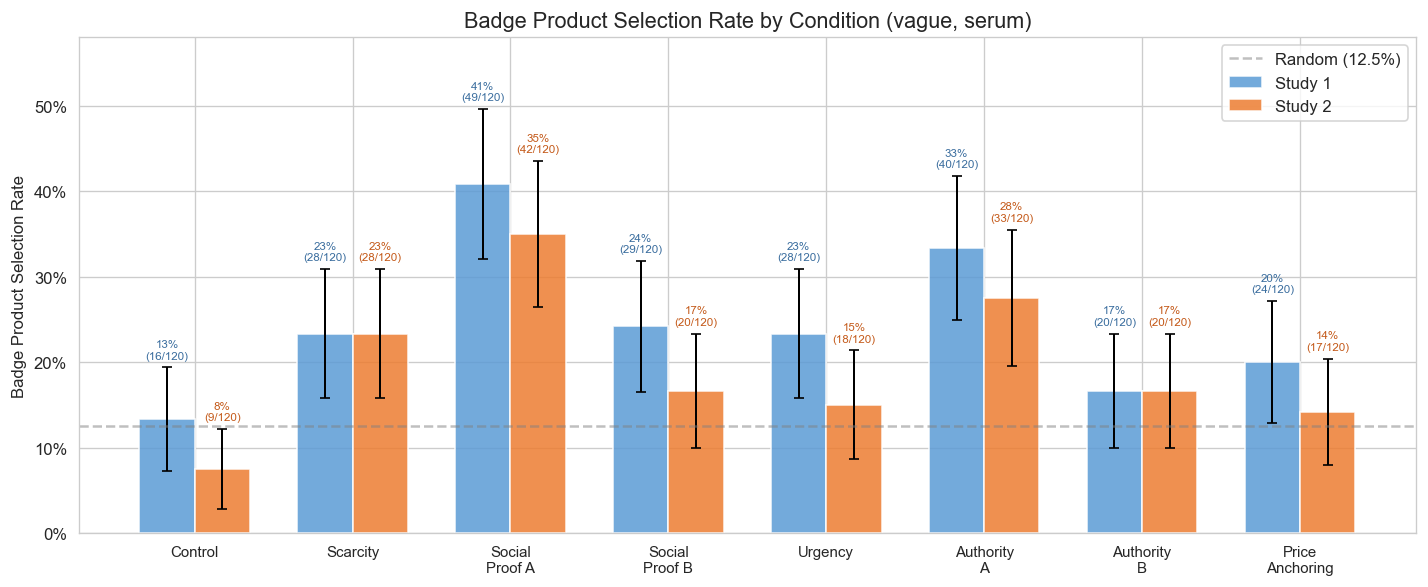

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
s1r, s2r = [], []
s1_elo, s1_ehi, s2_elo, s2_ehi = [], [], [], []
s1_counts, s2_counts, s1_totals, s2_totals = [], [], [], []
for c in CONDS:
    s1_sub = s1[s1['condition']==c]; s2_sub = s2[s2['condition']==c]
    p1, lo1, hi1 = ci(s1_sub['choseTarget'].sum(), len(s1_sub))
    p2, lo2, hi2 = ci(s2_sub['choseTarget'].sum(), len(s2_sub))
    s1r.append(p1); s2r.append(p2)
    s1_elo.append(p1-lo1); s1_ehi.append(hi1-p1)
    s2_elo.append(p2-lo2); s2_ehi.append(hi2-p2)
    s1_counts.append(int(s1_sub['choseTarget'].sum())); s1_totals.append(len(s1_sub))
    s2_counts.append(int(s2_sub['choseTarget'].sum())); s2_totals.append(len(s2_sub))

x = np.arange(len(CONDS)); w = 0.35
b1 = ax.bar(x-w/2, s1r, w, label='Study 1', color='#5B9BD5', alpha=0.85)
b2 = ax.bar(x+w/2, s2r, w, label='Study 2', color='#ED7D31', alpha=0.85)
ax.errorbar(x-w/2, s1r, yerr=[s1_elo, s1_ehi], fmt='none', color='black', capsize=3, linewidth=1.2)
ax.errorbar(x+w/2, s2r, yerr=[s2_elo, s2_ehi], fmt='none', color='black', capsize=3, linewidth=1.2)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.5, label='Random (12.5%)')
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS, fontsize=9)
ax.set_ylabel('Badge Product Selection Rate')
ax.set_title('Badge Product Selection Rate by Condition (vague, serum)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(); ax.set_ylim(0, 0.58)
for i in range(len(CONDS)):
    ax.text(x[i]-w/2, s1r[i]+s1_ehi[i]+0.01, f'{s1r[i]:.0%}\n({s1_counts[i]}/{s1_totals[i]})', ha='center', fontsize=7, color='#3a6d9e')
    ax.text(x[i]+w/2, s2r[i]+s2_ehi[i]+0.01, f'{s2r[i]:.0%}\n({s2_counts[i]}/{s2_totals[i]})', ha='center', fontsize=7, color='#c45a1a')
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig01_s1_vs_s2.png', dpi=150, bbox_inches='tight'); plt.show()

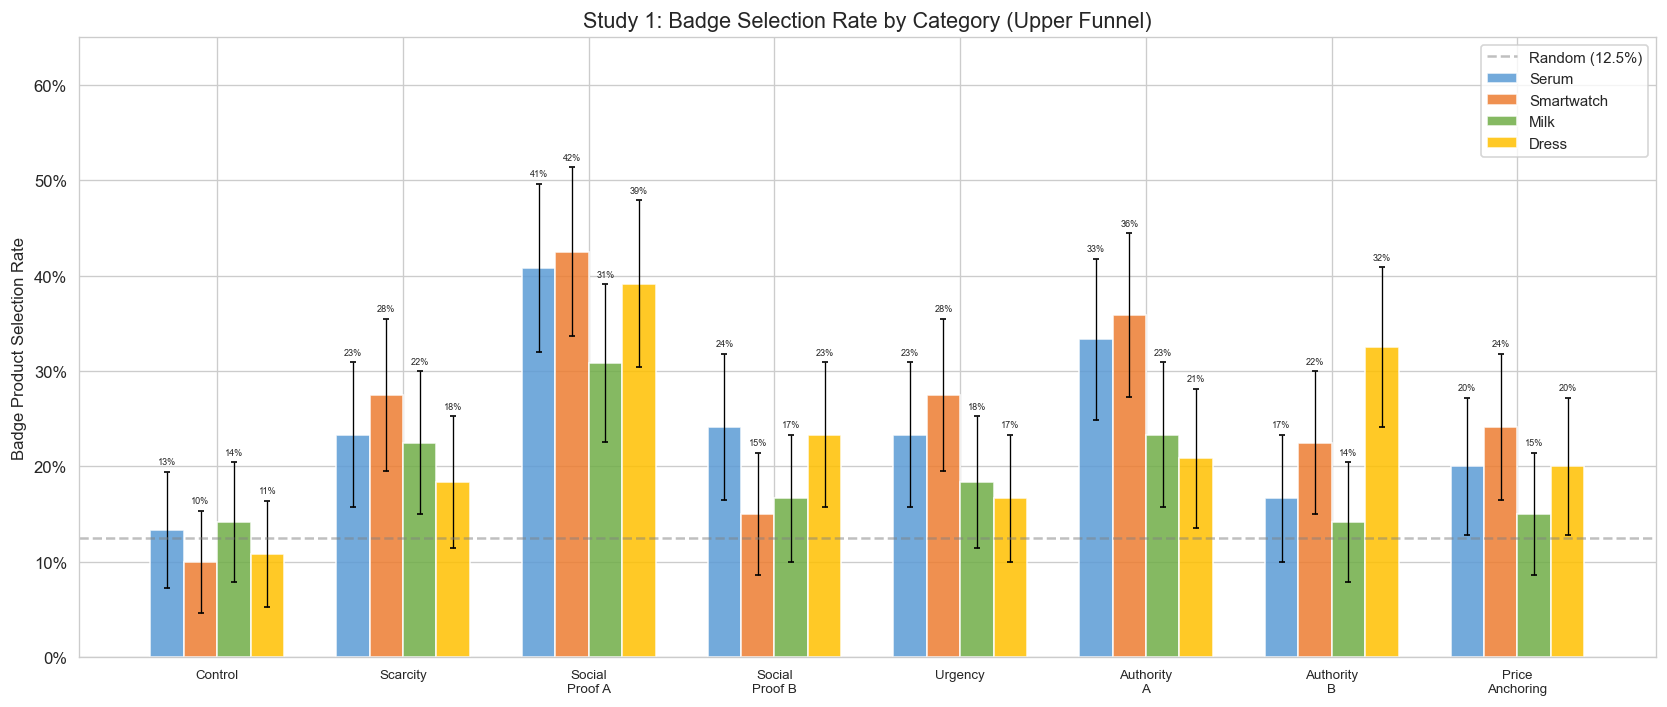

In [25]:
# ── 차트 1: Study 1 카테고리별 Badge Selection Rate (vague only) + CI ──
ac = 'promptType' if 'promptType' in s1_all.columns else 'agency'
s1v = s1_all[s1_all[ac]=='vague'].copy()
cats = ['serum','smartwatch','milk','dress']
cat_labels = ['Serum','Smartwatch','Milk','Dress']
cat_colors = ['#5B9BD5','#ED7D31','#70AD47','#FFC000']

fig, ax = plt.subplots(figsize=(14, 6))
w = 0.18
for i, cat in enumerate(cats):
    sub = s1v[s1v['categoryId']==cat]
    rates, elo, ehi = [], [], []
    for c in CONDS:
        csub = sub[sub['condition']==c]
        p, lo, hi = ci(csub['choseTarget'].sum(), len(csub))
        rates.append(p); elo.append(p-lo); ehi.append(hi-p)
    xpos = np.arange(len(CONDS))+i*w-1.5*w
    bars = ax.bar(xpos, rates, w, label=cat_labels[i], color=cat_colors[i], alpha=0.85)
    ax.errorbar(xpos, rates, yerr=[elo, ehi], fmt='none', color='black', capsize=2, linewidth=0.8)
    for j, bar in enumerate(bars):
        ax.text(bar.get_x()+bar.get_width()/2, rates[j]+ehi[j]+0.008,
                f'{rates[j]:.0%}', ha='center', fontsize=5.5)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.5, label='Random (12.5%)')
ax.set_xticks(range(len(CONDS))); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_ylabel('Badge Product Selection Rate')
ax.set_title('Study 1: Badge Selection Rate by Category (Upper Funnel)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=9); ax.set_ylim(0, 0.65)
plt.tight_layout(); plt.show()

In [27]:
# ── Funnel Position별 정확한 수치 확인 ──
ac = 'agency' if 'agency' in s1_serum.columns else 'promptType'
print(f'{"Condition":20s}', end='')
for a, fl in zip(AGENCIES, ['Upper','Middle','Lower','Defense']):
    print(f' {fl:>10s}', end='')
print()
print('-'*65)
for c in CONDS:
    print(f'{c:20s}', end='')
    for a in AGENCIES:
        sub = s1_serum[(s1_serum[ac]==a)&(s1_serum['condition']==c)]
        rate = sub['choseTarget'].mean()
        n = len(sub)
        print(f' {rate:>6.0%}({n:>3d})', end='')
    print()

Condition                 Upper     Middle      Lower    Defense
-----------------------------------------------------------------
control                 13%(120)    12%(120)    13%(120)    12%(120)
scarcity                23%(120)    22%(120)    15%(120)    12%(120)
social_proof_a          41%(120)    18%(120)    22%(120)    17%(120)
social_proof_b          24%(120)    15%(120)    17%(120)    25%(120)
urgency                 23%(120)    16%(120)    11%(120)    18%(120)
authority_a             33%(120)    27%(120)    17%(120)    13%(120)
authority_b             17%(120)    23%(120)    10%(120)    11%(120)
price_anchoring         20%(120)    18%(120)    21%(120)    17%(120)


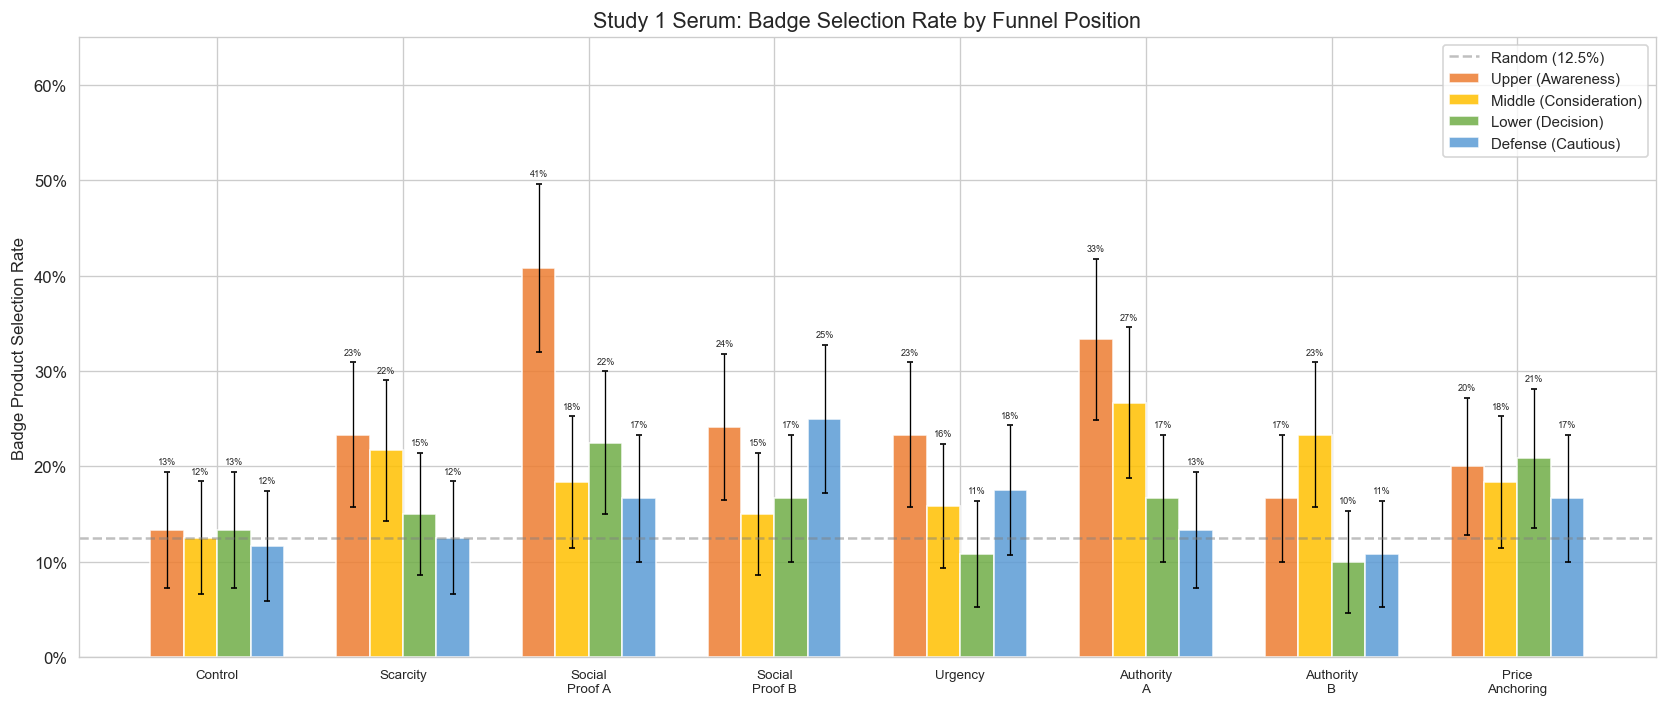

In [26]:
# ── 차트 2: Study 1 serum, Funnel Position별 Badge Selection Rate + CI ──
fig, ax = plt.subplots(figsize=(14, 6))
funnel_labels = ['Upper (Awareness)', 'Middle (Consideration)', 'Lower (Decision)', 'Defense (Cautious)']
funnel_colors = ['#ED7D31', '#FFC000', '#70AD47', '#5B9BD5']
w = 0.18
for i, a in enumerate(AGENCIES):
    sub = s1_serum[s1_serum['agency']==a] if 'agency' in s1_serum.columns else s1_serum[s1_serum['promptType']==a]
    rates, elo, ehi = [], [], []
    for c in CONDS:
        csub = sub[sub['condition']==c]
        p, lo, hi = ci(csub['choseTarget'].sum(), len(csub))
        rates.append(p); elo.append(p-lo); ehi.append(hi-p)
    xpos = np.arange(len(CONDS))+i*w-1.5*w
    bars = ax.bar(xpos, rates, w, label=funnel_labels[i], color=funnel_colors[i], alpha=0.85)
    ax.errorbar(xpos, rates, yerr=[elo, ehi], fmt='none', color='black', capsize=2, linewidth=0.8)
    for j, bar in enumerate(bars):
        ax.text(bar.get_x()+bar.get_width()/2, rates[j]+ehi[j]+0.008,
                f'{rates[j]:.0%}', ha='center', fontsize=5.5)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.5, label='Random (12.5%)')
ax.set_xticks(range(len(CONDS))); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_ylabel('Badge Product Selection Rate')
ax.set_title('Study 1 Serum: Badge Selection Rate by Funnel Position', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=9); ax.set_ylim(0, 0.65)
plt.tight_layout(); plt.show()

---
## 3. Input Mode × Condition

**목적:** 4개 input mode(text_json, text_flat, html, screenshot)와 8개 condition의 조합별 hit rate.
Agent가 정보를 받는 형식에 따라 nudge 효과가 달라지는지 확인.
- Heatmap: 전체 패턴 파악
- Small Multiples: mode별 S1 vs S2 직접 비교

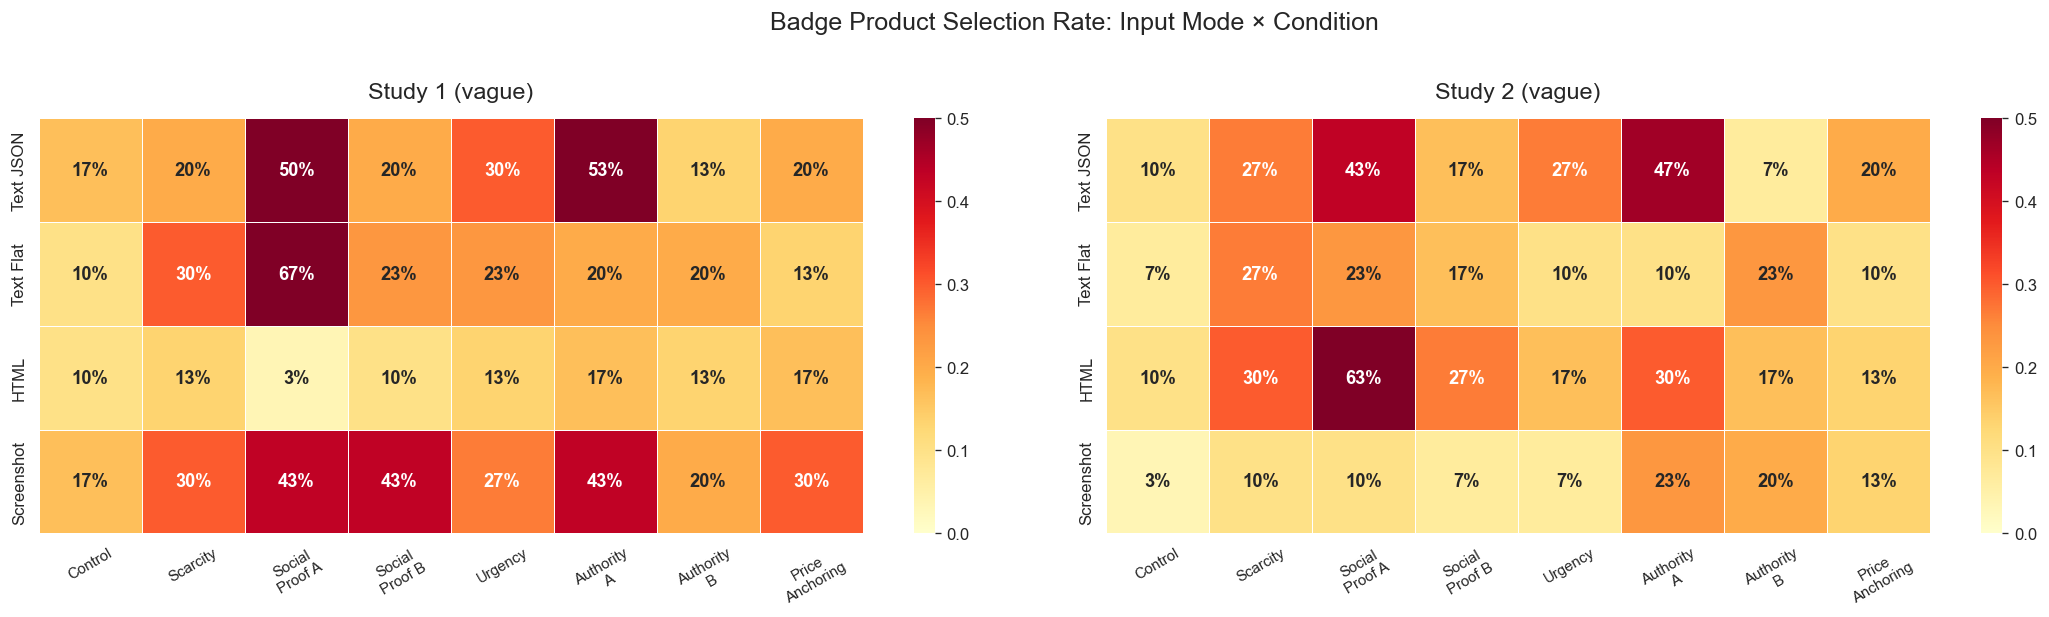

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for i, (df, t) in enumerate([(s1,'Study 1 (vague)'),(s2,'Study 2 (vague)')]):
    ax=axes[i]
    pivot = pd.DataFrame(
        {c: [df[(df['inputMode']==m)&(df['condition']==c)]['choseTarget'].mean() for m in MODES] for c in CONDS},
        index=MODE_LABELS)
    pivot.columns = COND_LABELS
    sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd', ax=ax, vmin=0, vmax=0.50,
                linewidths=0.5, linecolor='white', annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    ax.set_title(t, fontsize=14, pad=12); ax.set_ylabel(''); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=10)
plt.suptitle('Badge Product Selection Rate: Input Mode × Condition', fontsize=15, y=1.02)
plt.tight_layout(w_pad=4)
plt.savefig('../results/260314_1/study2/fig03_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

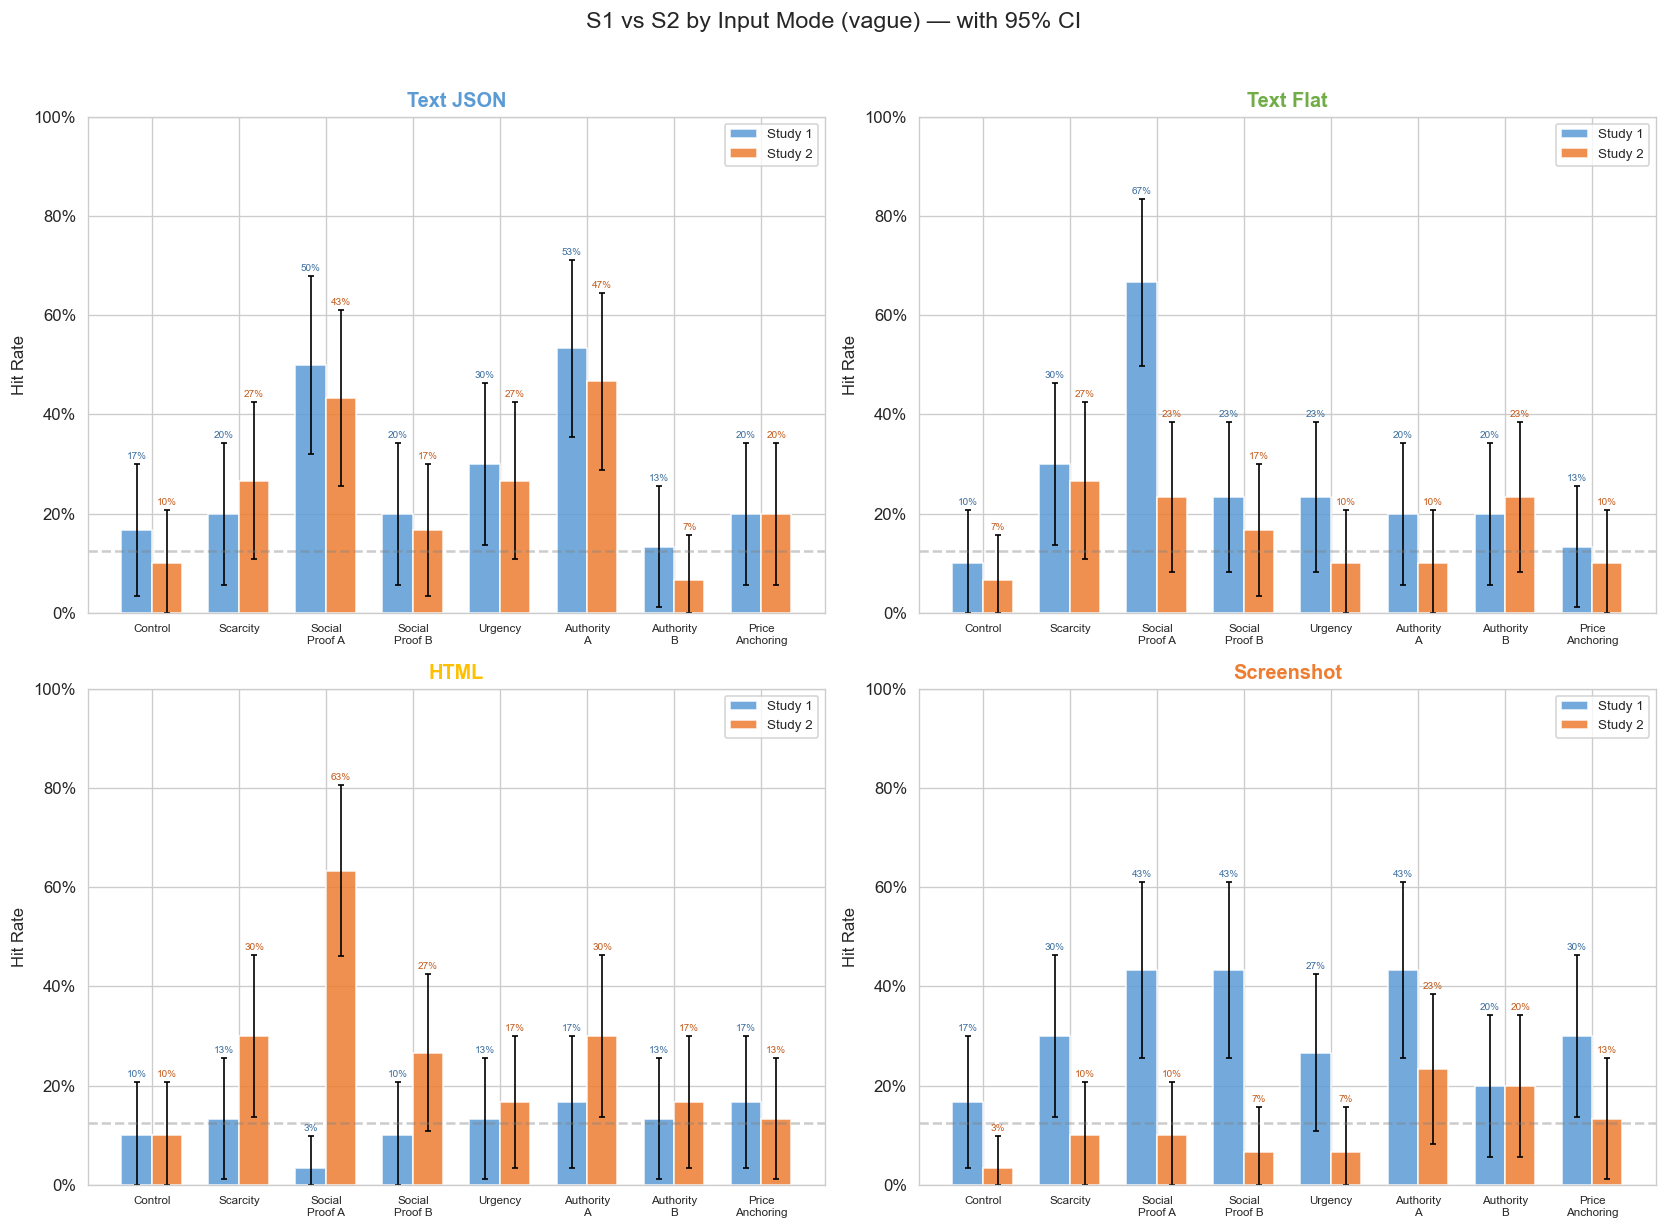

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
mode_colors = ['#5B9BD5','#70AD47','#FFC000','#ED7D31']
for idx, m in enumerate(MODES):
    ax=axes[idx//2][idx%2]
    s1r, s2r = [], []
    s1_elo, s1_ehi, s2_elo, s2_ehi = [], [], [], []
    for c in CONDS:
        s1_sub=s1[(s1['inputMode']==m)&(s1['condition']==c)]
        s2_sub=s2[(s2['inputMode']==m)&(s2['condition']==c)]
        p1,lo1,hi1=ci(s1_sub['choseTarget'].sum(),len(s1_sub))
        p2,lo2,hi2=ci(s2_sub['choseTarget'].sum(),len(s2_sub))
        s1r.append(p1); s2r.append(p2)
        s1_elo.append(p1-lo1); s1_ehi.append(hi1-p1)
        s2_elo.append(p2-lo2); s2_ehi.append(hi2-p2)
    x=np.arange(len(CONDS)); w=0.35
    b1=ax.bar(x-w/2, s1r, w, label='Study 1', color='#5B9BD5', alpha=0.85)
    b2=ax.bar(x+w/2, s2r, w, label='Study 2', color='#ED7D31', alpha=0.85)
    ax.errorbar(x-w/2, s1r, yerr=[s1_elo,s1_ehi], fmt='none', color='black', capsize=2, linewidth=1)
    ax.errorbar(x+w/2, s2r, yerr=[s2_elo,s2_ehi], fmt='none', color='black', capsize=2, linewidth=1)
    ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4)
    ax.set_xticks(x); ax.set_xticklabels(COND_LABELS, fontsize=7)
    ax.set_ylabel('Hit Rate'); ax.set_title(MODE_LABELS[idx], fontsize=12, color=mode_colors[idx], fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=8); ax.set_ylim(0, 1)
    for i in range(len(CONDS)):
        ax.text(x[i]-w/2, s1r[i]+s1_ehi[i]+0.01, f'{s1r[i]:.0%}', ha='center', fontsize=6, color='#3a6d9e')
        ax.text(x[i]+w/2, s2r[i]+s2_ehi[i]+0.01, f'{s2r[i]:.0%}', ha='center', fontsize=6, color='#c45a1a')
plt.suptitle('S1 vs S2 by Input Mode (vague) — with 95% CI', fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig03b_small_ci.png', dpi=150, bbox_inches='tight'); plt.show()

In [7]:
# viewedTarget이 아직 없으면 먼저 계산
if 'viewedTarget' not in s2.columns:
    def tin(row, col):
        vals=str(row[col]).split(',')
        t=str(int(row['targetProductId'])) if pd.notna(row['targetProductId']) else ''
        return t in vals if vals!=[''] and vals!=['nan'] else False
    s2['viewedTarget']=s2.apply(lambda r: tin(r,'productsViewed'), axis=1)
    s2['reviewedTarget']=s2.apply(lambda r: tin(r,'reviewsRead'), axis=1)
    
# ── 필요한 함수/변수가 없으면 먼저 정의 ──
if 'viewedTarget' not in s2.columns:
    def tin(row, col):
        vals=str(row[col]).split(',')
        t=str(int(row['targetProductId'])) if pd.notna(row['targetProductId']) else ''
        return t in vals if vals!=[''] and vals!=['nan'] else False
    s2['viewedTarget']=s2.apply(lambda r: tin(r,'productsViewed'), axis=1)
    s2['reviewedTarget']=s2.apply(lambda r: tin(r,'reviewsRead'), axis=1)

if 'has_kw' not in dir():
    NUDGE_KW = {
        'scarcity': ['only','left','stock','limited','hurry','few remaining'],
        'social_proof': ['best seller','popular','people','viewing','trending','#1'],
        'urgency': ['deal','ends','timer','hurry','limited time','countdown'],
        'authority': ['recommended','dermatologist','expert','clinically','certified','tested','editor'],
        'price_anchoring': ['was','save','discount','off','original','reduced'],
    }
    def has_kw(reasoning, condition):
        if pd.isna(reasoning): return False
        r=str(reasoning).lower()
        for prefix, kws in NUDGE_KW.items():
            if prefix in condition: return any(k in r for k in kws)
        return False

In [28]:
# ── Input Mode × Study 메커니즘 근거 (최신 데이터) ──
print('='*70)
print('근거 1: Mode별 탐색 행동 (Study 2, vague)')
print('='*70)
mode_stats = s2.groupby('inputMode').agg(
    n=('choseTarget','count'),
    hit_rate=('choseTarget','mean'),
    avg_steps=('totalSteps','mean'),
    avg_views=('viewCount','mean'),
    avg_reviews=('reviewCount','mean'),
    avg_searches=('searchCount','mean'),
    avg_tokens=('inputTokens','mean'),
    avg_cost=('estimatedCostUsd','mean'),
).reindex(MODES)
mode_stats.index = MODE_LABELS
print(mode_stats.to_string(float_format='{:.2f}'.format))

print('\n'+'='*70)
print('근거 2: Target 제품 engagement by mode')
print('='*70)
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    viewed = sub['viewedTarget'].mean()
    reviewed = sub['reviewedTarget'].mean()
    chose = sub['choseTarget'].mean()
    print(f'  {ml:12s}: viewed target={viewed:.1%}, reviewed target={reviewed:.1%}, chose target={chose:.1%}')

print('\n'+'='*70)
print('근거 3: Badge mention rate in reasoning by mode')
print('='*70)
treat = s2[s2['condition']!='control'].copy()
treat['mentions'] = treat.apply(lambda r: has_kw(r['reasoning'], r['condition']), axis=1)
for m, ml in zip(MODES, MODE_LABELS):
    sub = treat[treat['inputMode']==m]
    mention = sub['mentions'].mean()
    hit_w = sub[sub['mentions']==True]['choseTarget'].mean() if sub['mentions'].sum()>0 else 0
    hit_wo = sub[sub['mentions']==False]['choseTarget'].mean() if (~sub['mentions']).sum()>0 else 0
    print(f'  {ml:12s}: mention={mention:.1%}, hit|mentioned={hit_w:.1%}, hit|not={hit_wo:.1%}')

print('\n'+'='*70)
print('근거 4: Control hit rate by mode (S1 vs S2)')
print('='*70)
for m, ml in zip(MODES, MODE_LABELS):
    s1_ctrl = s1[(s1['inputMode']==m)&(s1['condition']=='control')]['choseTarget'].mean()
    s2_ctrl = s2[(s2['inputMode']==m)&(s2['condition']=='control')]['choseTarget'].mean()
    print(f'  {ml:12s}: S1 ctrl={s1_ctrl:.1%}, S2 ctrl={s2_ctrl:.1%}')

print('\n'+'='*70)
print('근거 5: S1 vs S2 hit rate by mode (treatment only)')
print('='*70)
for m, ml in zip(MODES, MODE_LABELS):
    s1_t = s1[(s1['inputMode']==m)&(s1['condition']!='control')]['choseTarget'].mean()
    s2_t = s2[(s2['inputMode']==m)&(s2['condition']!='control')]['choseTarget'].mean()
    diff = s2_t - s1_t
    print(f'  {ml:12s}: S1 treat={s1_t:.1%}, S2 treat={s2_t:.1%}, diff={diff:+.1%}')

근거 1: Mode별 탐색 행동 (Study 2, vague)
              n  hit_rate  avg_steps  avg_views  avg_reviews  avg_searches  avg_tokens  avg_cost
Text JSON   240      0.25       8.00       2.09         3.91          1.00     6094.71      0.00
Text Flat   240      0.16       8.70       1.78         4.92          1.00     4184.70      0.00
HTML        240      0.26       6.55       1.68         2.88          1.00    11276.92      0.00
Screenshot  240      0.12       8.40       3.93         2.47          1.00   211339.50      0.03

근거 2: Target 제품 engagement by mode
  Text JSON   : viewed target=36.7%, reviewed target=62.9%, chose target=24.6%
  Text Flat   : viewed target=22.1%, reviewed target=61.3%, chose target=15.8%
  HTML        : viewed target=28.7%, reviewed target=47.9%, chose target=25.8%
  Screenshot  : viewed target=20.4%, reviewed target=9.2%, chose target=11.7%

근거 3: Badge mention rate in reasoning by mode
  Text JSON   : mention=12.9%, hit|mentioned=77.8%, hit|not=19.1%
  Text Flat   : 

In [31]:
# ── Screenshot mode에서 target 제품의 view_product에 badge가 있는지 확인 ──
import json
from pathlib import Path

jsonl = Path('../results/260314_1/study2/serum_experiment_2026-03-14T06-39-32.jsonl')
trials = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]

# screenshot + authority_a에서 target을 view_product한 경우 찾기
for d in trials:
    if (d.get('inputMode') == 'screenshot' and d.get('condition') == 'authority_a' 
        and d.get('agency') == 'vague' and not d.get('_test')):
        target = d['targetProductId']
        for tc in d.get('toolCalls', []):
            if tc['tool'] == 'view_product' and tc['args'].get('product_id') == target:
                # target 제품을 view_product으로 본 경우
                has_badge = 'recommend' in tc['result'].lower() or 'badge' in tc['result'].lower()
                print(f"t{d['trialId']}: target={target}, viewed target=YES, badge in result={has_badge}")
                if not has_badge:
                    print(f"  ⚠️ BADGE MISSING! First 500 chars of result:")
                    print(f"  {tc['result'][:500]}")
                break

t2494: target=1, viewed target=YES, badge in result=True
t2506: target=4, viewed target=YES, badge in result=True
t2510: target=3, viewed target=YES, badge in result=True
t2513: target=1, viewed target=YES, badge in result=True
t2519: target=1, viewed target=YES, badge in result=True
t2520: target=6, viewed target=YES, badge in result=True


---
## 4. Agent Exploration Behavior (Study 2 전용)

**목적:** Multi-step agent가 실제로 어떻게 탐색하는지 분석.
- 총 steps, 검색 횟수, 제품 조회 횟수, 리뷰 읽은 횟수
- Input mode별 탐색 깊이 차이 (boxplot)
- Condition별 탐색 패턴과 hit rate의 관계

In [34]:
# ── Mode × Tool별 탐색 비율 (Study 2, vague) ──
print('=== Mode별 Search / View / Review 비율 (S2, vague) ===')
print(f'{"Mode":12s} {"N":>5s} {"Avg Steps":>10s} {"Avg Search":>11s} {"Avg View":>10s} {"Avg Review":>11s} {"Viewed Target":>14s} {"Reviewed Target":>16s} {"Hit Rate":>10s}')
print('-'*100)
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    n = len(sub)
    steps = sub['totalSteps'].mean()
    searches = sub['searchCount'].mean()
    views = sub['viewCount'].mean()
    reviews = sub['reviewCount'].mean()
    vt = sub['viewedTarget'].mean()
    rt = sub['reviewedTarget'].mean()
    hr = sub['choseTarget'].mean()
    print(f'{ml:12s} {n:>5d} {steps:>10.1f} {searches:>11.1f} {views:>10.1f} {reviews:>11.1f} {vt:>14.1%} {rt:>16.1%} {hr:>10.1%}')

# ── 전체 action 비율 (search/view/review가 전체 step에서 차지하는 비율) ──
print('\n=== 전체 Steps 중 Search / View / Review 비율 ===')
print(f'{"Mode":12s} {"Search %":>10s} {"View %":>10s} {"Review %":>10s} {"Select %":>10s}')
print('-'*55)
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    total = sub['totalSteps'].sum()
    s_pct = sub['searchCount'].sum() / total
    v_pct = sub['viewCount'].sum() / total
    r_pct = sub['reviewCount'].sum() / total
    sel_pct = 1 - s_pct - v_pct - r_pct  # select + other
    print(f'{ml:12s} {s_pct:>10.1%} {v_pct:>10.1%} {r_pct:>10.1%} {sel_pct:>10.1%}')

=== Mode별 Search / View / Review 비율 (S2, vague) ===
Mode             N  Avg Steps  Avg Search   Avg View  Avg Review  Viewed Target  Reviewed Target   Hit Rate
----------------------------------------------------------------------------------------------------
Text JSON      240        8.0         1.0        2.1         3.9          36.7%            62.9%      24.6%
Text Flat      240        8.7         1.0        1.8         4.9          22.1%            61.3%      15.8%
HTML           240        6.5         1.0        1.7         2.9          28.7%            47.9%      25.8%
Screenshot     240        8.4         1.0        3.9         2.5          20.4%             9.2%      11.7%

=== 전체 Steps 중 Search / View / Review 비율 ===
Mode           Search %     View %   Review %   Select %
-------------------------------------------------------
Text JSON         12.5%      26.1%      48.9%      12.5%
Text Flat         11.5%      20.5%      56.5%      11.5%
HTML              15.3%      25.6%

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_82438/3383001134.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_82438/3383001134.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_82438/3383001134.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/67/k4ct0mwx49j46bz5qfxg2

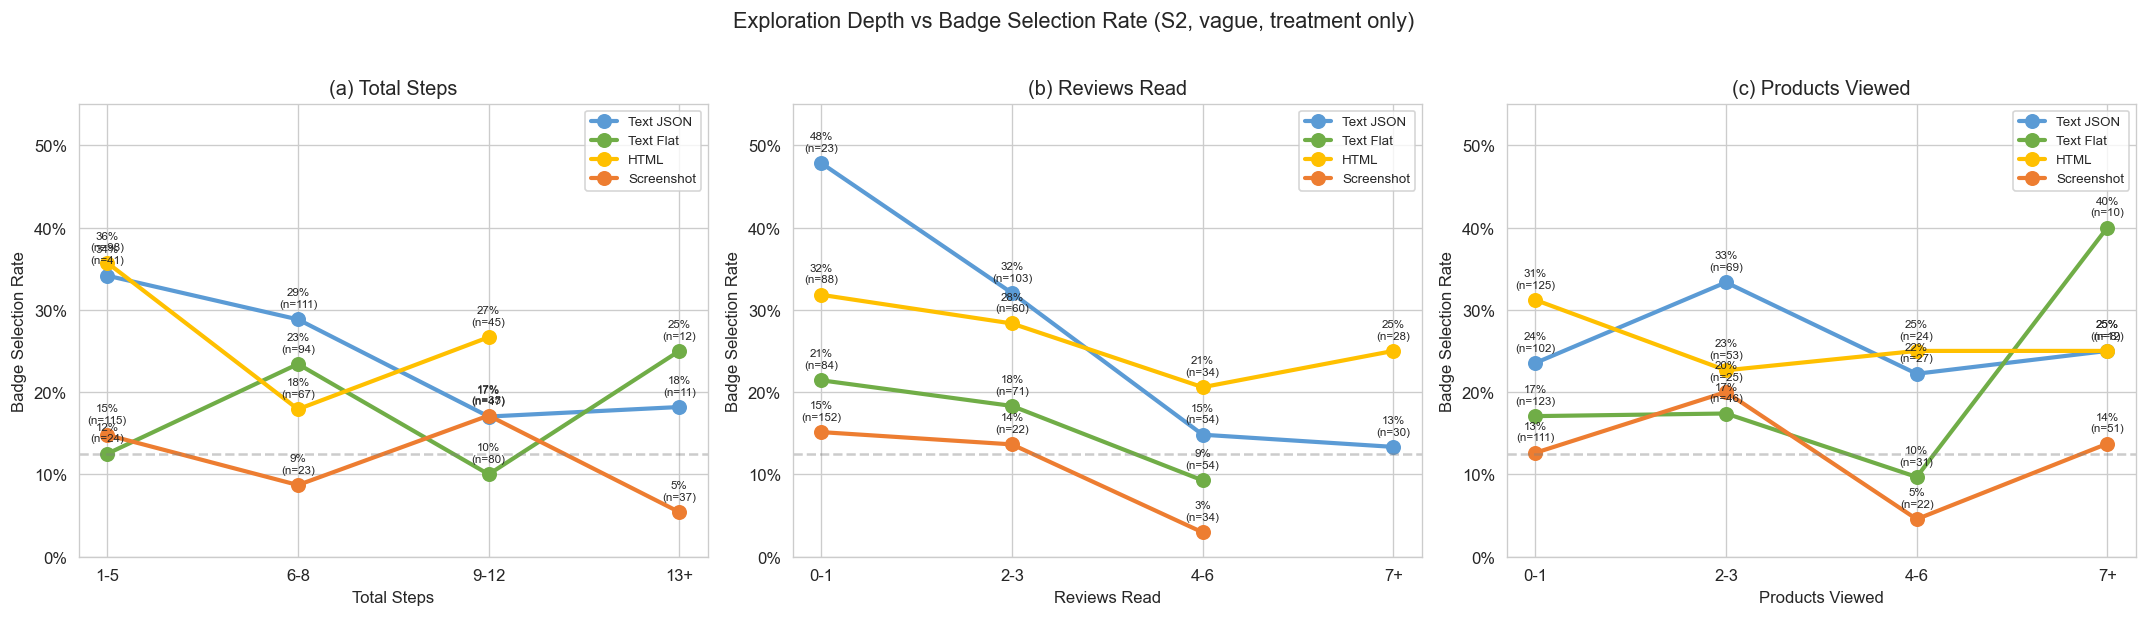

In [39]:
# ── 탐색 깊이 vs Badge Selection Rate (구간 binning, smoothed) ──
treat = s2[s2['condition']!='control'].copy()
mode_colors = {'text_json':'#5B9BD5','text_flat':'#70AD47','html':'#FFC000','screenshot':'#ED7D31'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Total Steps — 3구간
ax = axes[0]
for m, ml in zip(MODES, MODE_LABELS):
    sub = treat[treat['inputMode']==m]
    bins = pd.cut(sub['totalSteps'], bins=[0,5,8,12,50], labels=['1-5','6-8','9-12','13+'])
    grouped = sub.groupby(bins)['choseTarget'].agg(['mean','count'])
    grouped = grouped[grouped['count'] >= 5]
    ax.plot(range(len(grouped)), grouped['mean'], 'o-', color=mode_colors[m], label=ml, markersize=8, linewidth=2.5)
    for j, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(j, row['mean']+0.015, f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=7)
ax.set_xticks(range(4)); ax.set_xticklabels(['1-5','6-8','9-12','13+'])
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Total Steps'); ax.set_ylabel('Badge Selection Rate')
ax.set_title('(a) Total Steps', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=8); ax.set_ylim(0, 0.55)

# (b) Reviews Read — 3구간
ax = axes[1]
for m, ml in zip(MODES, MODE_LABELS):
    sub = treat[treat['inputMode']==m]
    bins = pd.cut(sub['reviewCount'], bins=[-1,1,3,6,30], labels=['0-1','2-3','4-6','7+'])
    grouped = sub.groupby(bins)['choseTarget'].agg(['mean','count'])
    grouped = grouped[grouped['count'] >= 5]
    ax.plot(range(len(grouped)), grouped['mean'], 'o-', color=mode_colors[m], label=ml, markersize=8, linewidth=2.5)
    for j, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(j, row['mean']+0.015, f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=7)
ax.set_xticks(range(4)); ax.set_xticklabels(['0-1','2-3','4-6','7+'])
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Reviews Read'); ax.set_ylabel('Badge Selection Rate')
ax.set_title('(b) Reviews Read', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=8); ax.set_ylim(0, 0.55)

# (c) Products Viewed — 3구간
ax = axes[2]
for m, ml in zip(MODES, MODE_LABELS):
    sub = treat[treat['inputMode']==m]
    bins = pd.cut(sub['viewCount'], bins=[-1,1,3,6,30], labels=['0-1','2-3','4-6','7+'])
    grouped = sub.groupby(bins)['choseTarget'].agg(['mean','count'])
    grouped = grouped[grouped['count'] >= 5]
    ax.plot(range(len(grouped)), grouped['mean'], 'o-', color=mode_colors[m], label=ml, markersize=8, linewidth=2.5)
    for j, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(j, row['mean']+0.015, f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=7)
ax.set_xticks(range(4)); ax.set_xticklabels(['0-1','2-3','4-6','7+'])
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Products Viewed'); ax.set_ylabel('Badge Selection Rate')
ax.set_title('(c) Products Viewed', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=8); ax.set_ylim(0, 0.55)

plt.suptitle('Exploration Depth vs Badge Selection Rate (S2, vague, treatment only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/260314_1/study2/fig_exploration_vs_nudge.png', dpi=150, bbox_inches='tight')
plt.show()

Avg steps:   7.9 (median 7)
Avg searches:1.0
Avg views:   2.4
Avg reviews: 3.5


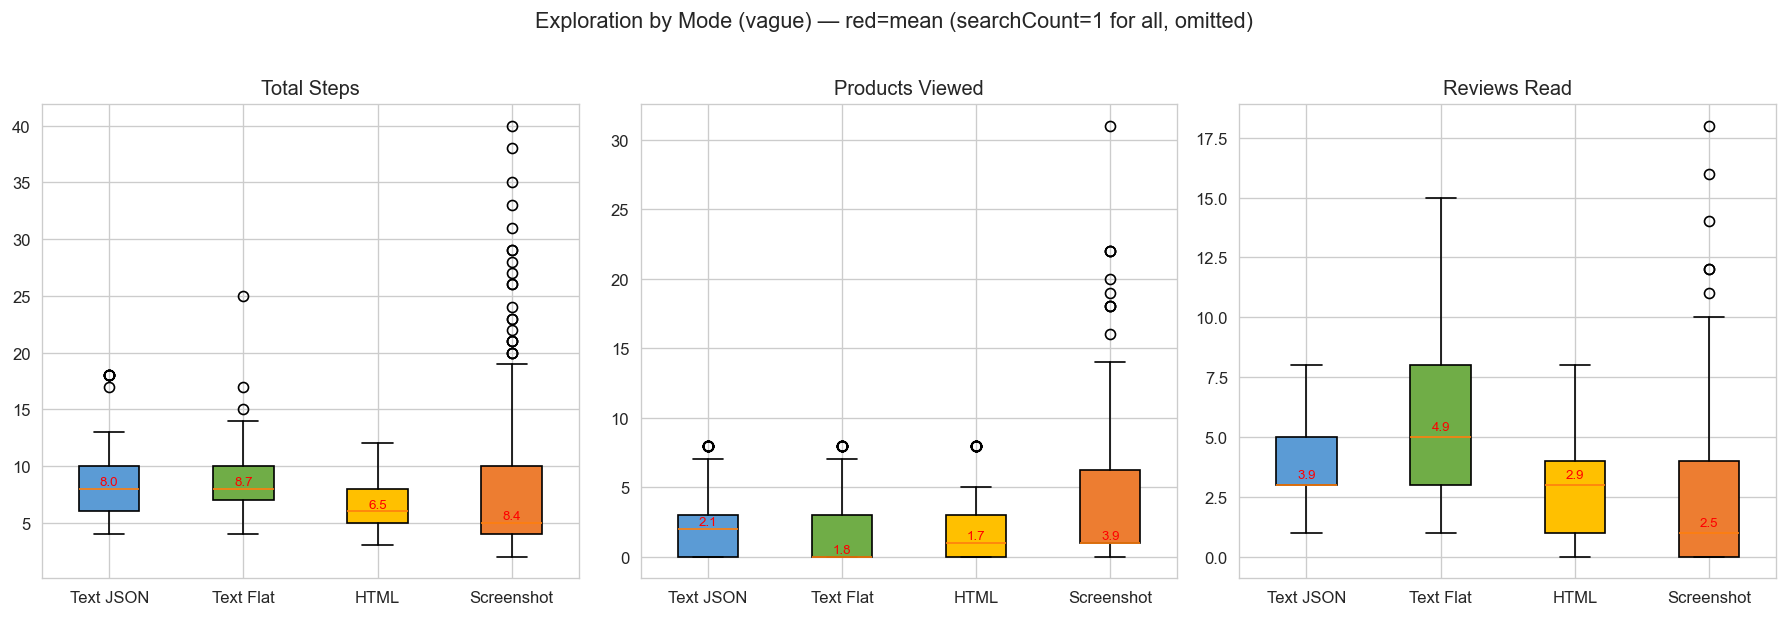

In [33]:
# ── 기본 통계 ──
print(f'Avg steps:   {s2["totalSteps"].mean():.1f} (median {s2["totalSteps"].median():.0f})')
print(f'Avg searches:{s2["searchCount"].mean():.1f}')
print(f'Avg views:   {s2["viewCount"].mean():.1f}')
print(f'Avg reviews: {s2["reviewCount"].mean():.1f}')

# ── searchCount 분산 체크 후 포함 여부 결정 ──
cols = [('totalSteps', 'Total Steps'),
        ('viewCount', 'Products Viewed'),
        ('reviewCount', 'Reviews Read')]

# searchCount에 분산이 있을 때만 포함
if s2['searchCount'].nunique() > 1:
    cols.insert(1, ('searchCount', 'Searches'))

n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]

for i, (col, t) in enumerate(cols):
    ax = axes[i]
    data = [s2[s2['inputMode']==m][col].dropna().values for m in MODES]
    bp = ax.boxplot(data, labels=MODE_LABELS, patch_artist=True)
    for p, c in zip(bp['boxes'], ['#5B9BD5','#70AD47','#FFC000','#ED7D31']):
        p.set_facecolor(c)
    ax.set_title(t)
    for j, d in enumerate(data):
        if len(d) > 0:
            ax.text(j+1, np.median(d)+0.3, f'{np.mean(d):.1f}',
                    ha='center', fontsize=8, color='red')

note = ' (searchCount=1 for all, omitted)' if s2['searchCount'].nunique() == 1 else ''
plt.suptitle(f'Exploration by Mode (vague) — red=mean{note}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/260314_1/study2/fig04_explore.png', dpi=150, bbox_inches='tight')
plt.show()

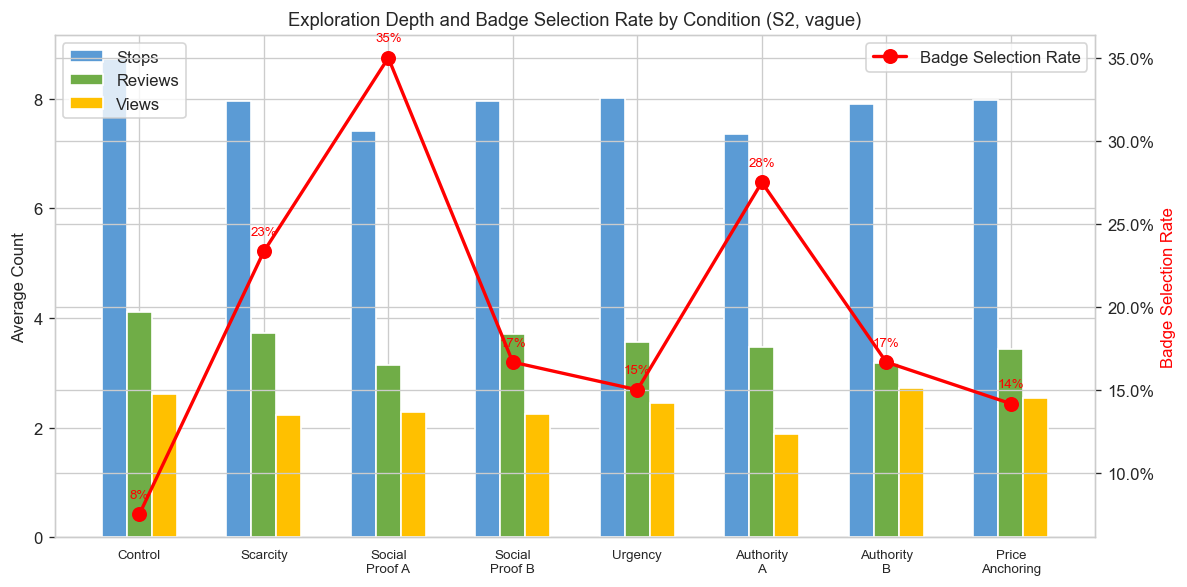

In [64]:
# ── Condition별 탐색 패턴 + Badge Selection Rate ──
fig, ax = plt.subplots(figsize=(10, 5))
e = s2.groupby('condition').agg(steps=('totalSteps','mean'), views=('viewCount','mean'),
    reviews=('reviewCount','mean'), hr=('choseTarget','mean')).reindex(CONDS)
x = np.arange(len(CONDS))
ax.bar(x-0.2, e['steps'], 0.2, label='Steps', color='#5B9BD5')
ax.bar(x, e['reviews'], 0.2, label='Reviews', color='#70AD47')
ax.bar(x+0.2, e['views'], 0.2, label='Views', color='#FFC000')
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_ylabel('Average Count'); ax.set_title('Exploration Depth and Badge Selection Rate by Condition (S2, vague)', fontsize=11)
ax.legend(loc='upper left')
ax2 = ax.twinx()
ax2.plot(x, e['hr'], 'ro-', linewidth=2, markersize=8, label='Badge Selection Rate')
for j, v in enumerate(e['hr']): ax2.text(j, v+0.01, f'{v:.0%}', ha='center', fontsize=8, color='red')
ax2.set_ylabel('Badge Selection Rate', color='red'); ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../results/260314_1/study2/fig04b_cond.png', dpi=150, bbox_inches='tight')
plt.show()

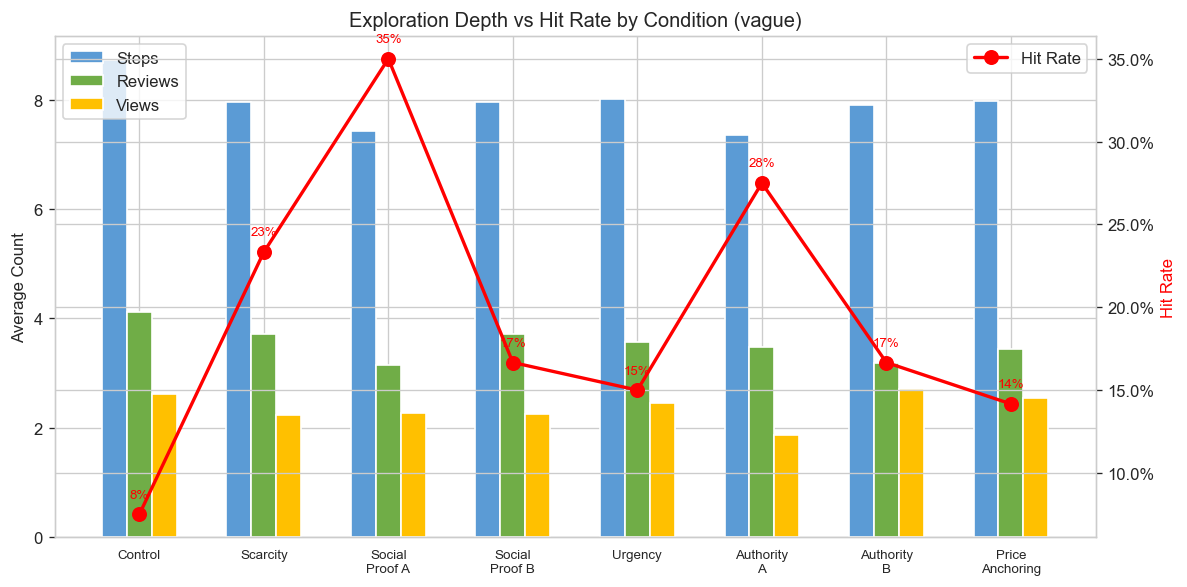

In [41]:
# ── Condition별 탐색 패턴 + Hit Rate 관계 ──
# 왼쪽 축: 탐색 깊이 (steps, reviews, views), 오른쪽 축: hit rate
# nudge가 탐색 행동을 바꾸는지 확인
fig, ax = plt.subplots(figsize=(10, 5))
e=s2.groupby('condition').agg(steps=('totalSteps','mean'),views=('viewCount','mean'),reviews=('reviewCount','mean'),hr=('choseTarget','mean')).reindex(CONDS)
x=np.arange(len(CONDS))
ax.bar(x-0.2, e['steps'], 0.2, label='Steps', color='#5B9BD5')
ax.bar(x, e['reviews'], 0.2, label='Reviews', color='#70AD47')
ax.bar(x+0.2, e['views'], 0.2, label='Views', color='#FFC000')
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_ylabel('Average Count'); ax.set_title('Exploration Depth vs Hit Rate by Condition (vague)'); ax.legend(loc='upper left')
ax2=ax.twinx()
ax2.plot(x, e['hr'], 'ro-', linewidth=2, markersize=8, label='Hit Rate')
for j, v in enumerate(e['hr']): ax2.text(j, v+0.01, f'{v:.0%}', ha='center', fontsize=8, color='red')
ax2.set_ylabel('Hit Rate', color='red'); ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(loc='upper right')
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig04b_cond.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 5. Tool Call Trajectories

**목적:** Agent가 어떤 순서로 tool을 호출하는지 패턴 분석.
- 가장 빈번한 tool call sequence Top 15
- 각 패턴의 hit rate 확인 → 특정 탐색 패턴이 nudge에 더 취약한지 파악

In [45]:
seq=s2['toolCallSequence'].value_counts().head(15)
print('=== Top 15 Trajectories (vague) ===')
print(f'{"Count":>6s} {"Pct":>6s} {"Hit":>6s}   Sequence')
print('-'*80)
for s, cnt in seq.items():
    hit=s2[s2['toolCallSequence']==s]['choseTarget'].mean()
    print(f'{cnt:6d} {cnt/len(s2)*100:5.1f}% {hit:5.0%}   {s}')

=== Top 15 Trajectories (vague) ===
 Count    Pct    Hit   Sequence
--------------------------------------------------------------------------------
   119  12.4%   14%   S -> R -> R -> R -> R -> R -> R -> R -> R -> P
    88   9.2%   23%   S -> V -> V -> V -> R -> R -> R -> P
    86   9.0%   24%   S -> R -> R -> R -> P
    73   7.6%   15%   S -> R -> R -> R -> R -> R -> P
    68   7.1%    7%   S -> V -> R -> P
    50   5.2%   20%   S -> V -> V -> V -> P
    46   4.8%   17%   S -> R -> R -> R -> R -> P
    38   4.0%   42%   S -> R -> V -> P
    32   3.3%   19%   S -> R -> P
    30   3.1%   13%   S -> V -> V -> V -> V -> V -> R -> R -> R -> R -> R -> P
    22   2.3%   36%   S -> V -> V -> V -> V -> V -> V -> V -> V -> P
    17   1.8%   18%   S -> R -> R -> R -> V -> V -> V -> P
    16   1.7%   25%   S -> V -> V -> V -> V -> R -> R -> R -> R -> P
    14   1.5%   36%   S -> R -> R -> R -> V -> P
    14   1.5%   14%   S -> V -> V -> V -> V -> P


In [46]:
seq = s2['toolCallSequence'].value_counts().head(7)
label_map = {'S':'Search page', 'R':'Review page', 'V':'Product view', 'P':'Select product'}

def translate_seq(s):
    return ' → '.join(label_map.get(x.strip(), x.strip()) for x in s.split(' -> '))

print('=== Top 7 Trajectories (vague) ===')
print(f'{"Count":>6s} {"Pct":>6s} {"Hit":>6s}   Sequence')
print('-'*100)
for s, cnt in seq.items():
    hit = s2[s2['toolCallSequence']==s]['choseTarget'].mean()
    print(f'{cnt:6d} {cnt/len(s2)*100:5.1f}% {hit:5.0%}   {translate_seq(s)}')

=== Top 7 Trajectories (vague) ===
 Count    Pct    Hit   Sequence
----------------------------------------------------------------------------------------------------
   119  12.4%   14%   Search page → Review page → Review page → Review page → Review page → Review page → Review page → Review page → Review page → Select product
    88   9.2%   23%   Search page → Product view → Product view → Product view → Review page → Review page → Review page → Select product
    86   9.0%   24%   Search page → Review page → Review page → Review page → Select product
    73   7.6%   15%   Search page → Review page → Review page → Review page → Review page → Review page → Select product
    68   7.1%    7%   Search page → Product view → Review page → Select product
    50   5.2%   20%   Search page → Product view → Product view → Product view → Select product
    46   4.8%   17%   Search page → Review page → Review page → Review page → Review page → Select product


In [49]:
# ── Mode별 Top 7 Trajectories ──
label_map = {'S':'Search page', 'R':'Review page', 'V':'Product view', 'P':'Select product'}

def translate_seq(s):
    return ' → '.join(label_map.get(x.strip(), x.strip()) for x in s.split(' -> '))

for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    seq = sub['toolCallSequence'].value_counts().head(7)
    print(f'\n{"="*100}')
    print(f'{ml} (n={len(sub)})')
    print(f'{"="*100}')
    print(f'{"Count":>6s} {"Pct":>6s} {"Hit":>6s}   Sequence')
    print(f'{"-"*100}')
    for s, cnt in seq.items():
        hit = sub[sub['toolCallSequence']==s]['choseTarget'].mean()
        print(f'{cnt:6d} {cnt/len(sub)*100:5.1f}% {hit:5.0%}   {translate_seq(s)}')


Text JSON (n=240)
 Count    Pct    Hit   Sequence
----------------------------------------------------------------------------------------------------
    51  21.2%   25%   Search page → Product view → Product view → Product view → Review page → Review page → Review page → Select product
    29  12.1%   28%   Search page → Review page → Review page → Review page → Select product
    27  11.2%   11%   Search page → Review page → Review page → Review page → Review page → Review page → Review page → Review page → Review page → Select product
    20   8.3%    5%   Search page → Review page → Review page → Review page → Review page → Review page → Select product
    13   5.4%    0%   Search page → Product view → Product view → Product view → Product view → Product view → Review page → Review page → Review page → Review page → Review page → Select product
    12   5.0%   25%   Search page → Review page → Review page → Review page → Review page → Select product
     8   3.3%   50%   Search p

In [47]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

label_map = {'S': 'Search', 'R': 'Review', 'V': 'View', 'P': 'Select'}
nodes = ['Search', 'Review', 'View', 'Select']
node_idx = {v: i for i, v in enumerate(nodes)}

color_node = [
    'rgba(127,119,221,0.85)',
    'rgba(29,158,117,0.85)',
    'rgba(55,138,221,0.85)',
    'rgba(216,90,48,0.85)',
]
color_link = {
    'S': 'rgba(127,119,221,0.3)',
    'R': 'rgba(29,158,117,0.3)',
    'V': 'rgba(55,138,221,0.3)',
    'P': 'rgba(216,90,48,0.3)',
}

fig = make_subplots(rows=2, cols=2,
    subplot_titles=['Text JSON','Text Flat','HTML','Screenshot'],
    specs=[[{"type":"sankey"},{"type":"sankey"}],[{"type":"sankey"},{"type":"sankey"}]])

for idx, (m, ml) in enumerate(zip(MODES, MODE_LABELS)):
    sub = s2[s2['inputMode']==m]
    trans = {}
    total = 0
    for seq_str, cnt in sub['toolCallSequence'].value_counts().items():
        steps = [s.strip() for s in seq_str.split(' -> ')]
        for i in range(len(steps)-1):
            pair = (steps[i], steps[i+1])
            trans[pair] = trans.get(pair, 0) + cnt
        total += cnt
    
    sources, targets, values, lcolors = [], [], [], []
    for (src, tgt), val in sorted(trans.items(), key=lambda x: -x[1]):
        if src in label_map and tgt in label_map:
            sources.append(node_idx[label_map[src]])
            targets.append(node_idx[label_map[tgt]])
            values.append(val)
            lcolors.append(color_link[src])
    
    row, col = idx//2+1, idx%2+1
    fig.add_trace(go.Sankey(
        node=dict(pad=20, thickness=20, label=nodes, color=color_node),
        link=dict(source=sources, target=targets, value=values, color=lcolors),
    ), row=row, col=col)

fig.update_layout(
    title_text='Agent Journey by Input Mode (S2, vague)',
    font=dict(size=12), width=1000, height=700,
    margin=dict(l=20, r=20, t=80, b=20),
)
fig.show()

In [61]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

label_map = {'S': 'Search', 'R': 'Review', 'V': 'View', 'P': 'Select'}
nodes = ['Search', 'Review', 'View', 'Select']
node_idx = {v: i for i, v in enumerate(nodes)}

color_node = [
    'rgba(127,119,221,0.85)',
    'rgba(29,158,117,0.85)',
    'rgba(55,138,221,0.85)',
    'rgba(216,90,48,0.85)',
]
color_link = {
    'S': 'rgba(127,119,221,0.3)',
    'R': 'rgba(29,158,117,0.3)',
    'V': 'rgba(55,138,221,0.3)',
    'P': 'rgba(216,90,48,0.3)',
}

funnel_labels = ['Upper (Awareness)', 'Middle (Consideration)', 'Lower (Decision)', 'Defense (Cautious)']

fig = make_subplots(rows=2, cols=2,
    subplot_titles=funnel_labels,
    specs=[[{"type":"sankey"},{"type":"sankey"}],[{"type":"sankey"},{"type":"sankey"}]])

for idx, (a, fl) in enumerate(zip(AGENCIES, funnel_labels)):
    sub = s2_all[s2_all['agency']==a]
    trans = {}
    total = 0
    for seq_str, cnt in sub['toolCallSequence'].value_counts().items():
        steps = [s.strip() for s in seq_str.split(' -> ')]
        for i in range(len(steps)-1):
            pair = (steps[i], steps[i+1])
            trans[pair] = trans.get(pair, 0) + cnt
        total += cnt
    
    sources, targets, values, lcolors = [], [], [], []
    for (src, tgt), val in sorted(trans.items(), key=lambda x: -x[1]):
        if src in label_map and tgt in label_map:
            sources.append(node_idx[label_map[src]])
            targets.append(node_idx[label_map[tgt]])
            values.append(val)
            lcolors.append(color_link[src])
    
    row, col = idx//2+1, idx%2+1
    fig.add_trace(go.Sankey(
        node=dict(pad=20, thickness=20, label=nodes, color=color_node),
        link=dict(source=sources, target=targets, value=values, color=lcolors),
    ), row=row, col=col)

fig.update_layout(
    title_text='Agent Journey by Funnel Position (S2, serum)',
    font=dict(size=12), width=1000, height=700,
    margin=dict(l=20, r=20, t=80, b=20),
)
fig.show()

In [66]:
from IPython.display import display

# ── Input Mode별 ──
print('=== Input Mode별 탐색 행동 & Badge Selection Rate (S2, vague) ===')
e2 = s2.groupby('inputMode').agg(
    steps=('totalSteps','mean'),
    views=('viewCount','mean'),
    reviews=('reviewCount','mean'),
    viewed_target=('viewedTarget','mean'),
    reviewed_target=('reviewedTarget','mean'),
    hr=('choseTarget','mean')
).reindex(MODES)
e2.index = MODE_LABELS
e2 = e2.rename(columns={
    'steps':'Avg Steps','views':'Avg Views','reviews':'Avg Reviews',
    'viewed_target':'Viewed Target','reviewed_target':'Reviewed Target','hr':'Badge Selection Rate'})
display(e2.style.format({
    'Avg Steps':'{:.1f}','Avg Views':'{:.1f}','Avg Reviews':'{:.1f}',
    'Viewed Target':'{:.1%}','Reviewed Target':'{:.1%}','Badge Selection Rate':'{:.1%}'}
).set_properties(**{'text-align':'center'}))

# ── 전체 평균 ──
print('\n=== 전체 평균 (S2, vague) ===')
total = pd.DataFrame({
    'Avg Steps': [s2['totalSteps'].mean()],
    'Avg Views': [s2['viewCount'].mean()],
    'Avg Reviews': [s2['reviewCount'].mean()],
    'Viewed Target': [s2['viewedTarget'].mean()],
    'Reviewed Target': [s2['reviewedTarget'].mean()],
    'Badge Selection Rate': [s2['choseTarget'].mean()],
}, index=['Overall'])
display(total.style.format({
    'Avg Steps':'{:.1f}','Avg Views':'{:.1f}','Avg Reviews':'{:.1f}',
    'Viewed Target':'{:.1%}','Reviewed Target':'{:.1%}','Badge Selection Rate':'{:.1%}'}
).set_properties(**{'text-align':'center'}))

=== Input Mode별 탐색 행동 & Badge Selection Rate (S2, vague) ===


,Avg Steps,Avg Views,Avg Reviews,Viewed Target,Reviewed Target,Badge Selection Rate
Text JSON,8.0,2.1,3.9,36.7%,62.9%,24.6%
Text Flat,8.7,1.8,4.9,22.1%,61.3%,15.8%
HTML,6.5,1.7,2.9,28.7%,47.9%,25.8%
Screenshot,8.4,3.9,2.5,20.4%,9.2%,11.7%



=== 전체 평균 (S2, vague) ===


,Avg Steps,Avg Views,Avg Reviews,Viewed Target,Reviewed Target,Badge Selection Rate
Overall,7.9,2.4,3.5,27.0%,45.3%,19.5%


In [44]:
import plotly.graph_objects as go
import numpy as np

# ── 전이 집계 ────────────────────────────────────────────────
label_map = {'S': 'Search page', 'R': 'Review page', 'V': 'Product view', 'P': 'Select product'}
keys = ['S', 'R', 'V', 'P']
names = [label_map[k] for k in keys]

trans = {}
total = 0
for seq_str, cnt in s2['toolCallSequence'].value_counts().items():
    steps = [s.strip() for s in seq_str.split(' -> ')]
    for i in range(len(steps) - 1):
        pair = (steps[i], steps[i+1])
        trans[pair] = trans.get(pair, 0) + cnt
    total += cnt

total_trans = sum(trans.values())
self_loops = {}
non_loops = {}
for (s, t), v in trans.items():
    if s == t:
        self_loops[s] = v
    else:
        non_loops[(s, t)] = v

# ══════════════════════════════════════════════════════════════
# 1) Sankey — 수동 배치, annotation으로 수치 표시
# ══════════════════════════════════════════════════════════════
#  S(0)  R(1)  V(2)  P(3)  — 순방향 전용
#  R_back(4)  V_back(5)    — 역방향 수신 노드 (R←V, V←R)
# 역방향 링크를 별도 노드로 만들어 self-loop/역방향 문제 해결

# 순방향만 Sankey에 넣고, 역방향+self-loop는 annotation으로 표시
forward_pairs = [('S','R'), ('S','V'), ('S','P'), ('R','V'), ('R','P'), ('V','P')]
backward_pairs = [('V','R'), ('R','S'), ('V','S'), ('P','R'), ('P','V'), ('P','S')]

node_idx = {k: i for i, k in enumerate(keys)}
color_node = ['rgba(127,119,221,0.85)', 'rgba(29,158,117,0.85)',
              'rgba(55,138,221,0.85)', 'rgba(216,90,48,0.85)']
color_link_map = {'S':'rgba(127,119,221,0.4)', 'R':'rgba(29,158,117,0.4)',
                  'V':'rgba(55,138,221,0.4)', 'P':'rgba(216,90,48,0.4)'}

sources, targets, values, lcolors = [], [], [], []
link_info = []  # for annotations

for (src, tgt), val in sorted(non_loops.items(), key=lambda x: -x[1]):
    sources.append(node_idx[src])
    targets.append(node_idx[tgt])
    values.append(val)
    lcolors.append(color_link_map[src])
    pct = val / total_trans * 100
    link_info.append({'src': src, 'tgt': tgt, 'val': val, 'pct': pct})

node_x = [0.01, 0.35, 0.65, 0.99]
node_y = [0.5,  0.4,  0.6,  0.5]

fig1 = go.Figure(go.Sankey(
    arrangement='fixed',
    node=dict(pad=50, thickness=25,
              line=dict(color='rgba(0,0,0,0.2)', width=0.5),
              label=names, color=color_node,
              x=node_x, y=node_y),
    link=dict(source=sources, target=targets, value=values, color=lcolors),
))

# ── Annotation: 모든 전이 수치 표시 ──────────────────────────
# 링크 중간 위치 근사
pos = {'S': (0.01, 0.5), 'R': (0.35, 0.4), 'V': (0.65, 0.6), 'P': (0.99, 0.5)}
annotations = []

# self-loop
for k, val in self_loops.items():
    px, py = pos[k]
    pct = val / total_trans * 100
    annotations.append(dict(
        x=px, y=py - 0.15, xref='paper', yref='paper',
        text=f'<b>↻ {val:,} ({pct:.1f}%)</b>',
        showarrow=False, font=dict(size=11, color=color_node[keys.index(k)]),
        bgcolor='rgba(255,255,255,0.8)', borderpad=3,
    ))

# 전이 링크 — 중간 지점에 표시
shown = set()
offset_counter = {}
for info in sorted(link_info, key=lambda x: -x['val']):
    s, t = info['src'], info['tgt']
    sx, sy = pos[s]
    tx, ty = pos[t]
    mx, my = (sx + tx) / 2, (sy + ty) / 2

    # 같은 중간점에 여러 개 겹치면 offset
    mid_key = (round(mx, 2), round(my, 2))
    offset_counter[mid_key] = offset_counter.get(mid_key, 0)
    offset = offset_counter[mid_key] * 0.06
    offset_counter[mid_key] += 1

    annotations.append(dict(
        x=mx, y=my + offset, xref='paper', yref='paper',
        text=f'{label_map[s][0]}→{label_map[t][0]}: {info["val"]:,} ({info["pct"]:.1f}%)',
        showarrow=False, font=dict(size=10),
        bgcolor='rgba(255,255,255,0.85)', borderpad=2,
    ))

fig1.update_layout(
    title=f'User journey Sankey (n={total:,}, total transitions={total_trans:,})',
    font=dict(size=13), width=1100, height=600,
    margin=dict(l=20, r=20, t=60, b=20),
    annotations=annotations,
)
fig1.show()

# ══════════════════════════════════════════════════════════════
# 2) Transition matrix heatmap
# ══════════════════════════════════════════════════════════════
mat = np.zeros((4, 4), dtype=int)
for (src, tgt), val in trans.items():
    mat[keys.index(src)][keys.index(tgt)] = val

annot = [[f'{mat[i][j]:,}<br>({mat[i][j]/total_trans*100:.1f}%)' for j in range(4)] for i in range(4)]

fig2 = go.Figure(go.Heatmap(
    z=mat, x=names, y=names,
    text=annot, texttemplate='%{text}', textfont=dict(size=14),
    colorscale=[[0,'#e0f2f1'],[0.15,'#80cbc4'],[0.4,'#26a69a'],[1,'#004d40']],
    showscale=True, colorbar=dict(title='Count'),
    hovertemplate='%{y} → %{x}<br>Count: %{z:,}<extra></extra>',
))
fig2.update_layout(
    title=f'Transition matrix (total transitions={total_trans:,})',
    xaxis=dict(title='To (next page)', side='bottom'),
    yaxis=dict(title='From (current page)', autorange='reversed'),
    font=dict(size=13), width=700, height=600,
    margin=dict(l=130, r=20, t=60, b=100),
)
fig2.show()

---
## 6. Exploration Depth vs Hit Rate

**목적:** 더 많이 탐색하면 nudge 효과가 줄어드는가?
- 왼쪽: Depth bin별 control vs treatment hit rate → 탐색 깊이와 nudge 효과의 관계
- 오른쪽: Hit한 trial vs Miss한 trial의 step 분포 → hit한 경우가 더 적게/많이 탐색했는지

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_10588/4147719645.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_10588/4147719645.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



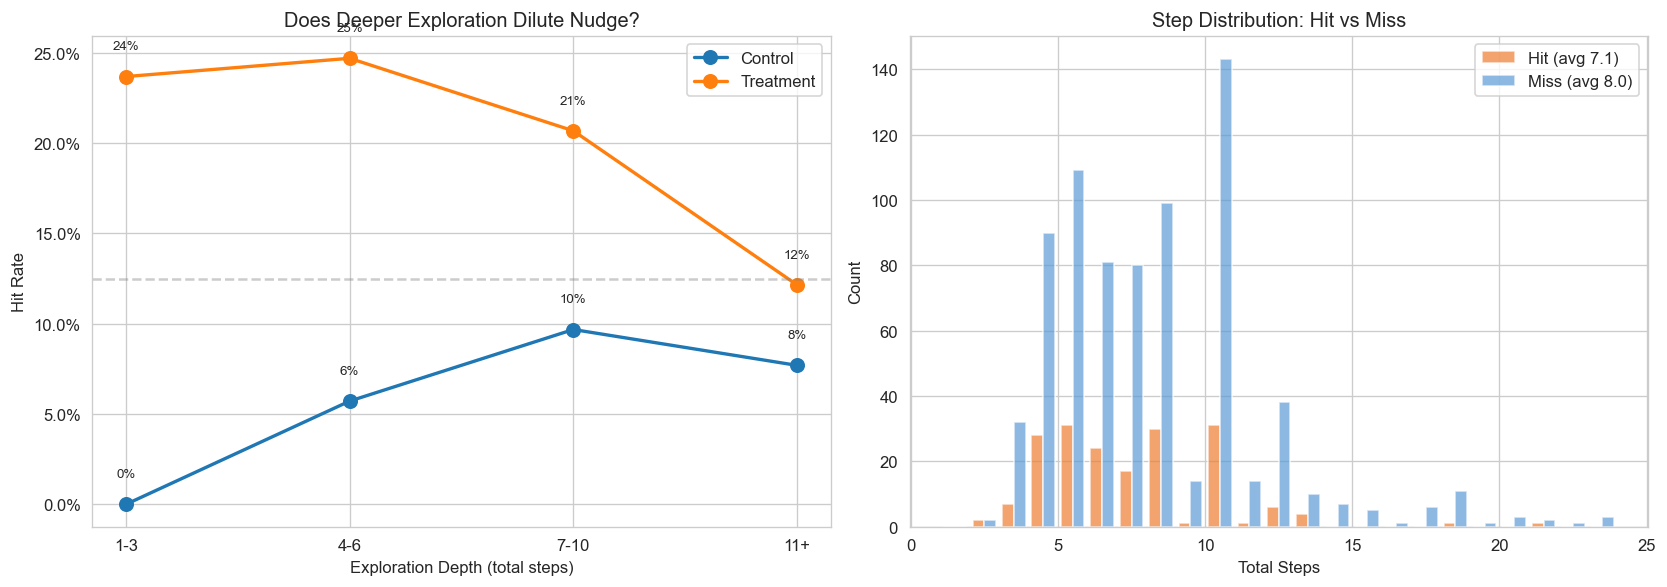

Mann-Whitney p=1.1283e-02


In [ ]:
s2['depth_bin']=pd.cut(s2['totalSteps'], bins=[0,3,6,10,30], labels=['1-3','4-6','7-10','11+'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: depth별 control vs treatment
ax=axes[0]
for lbl, sub in [('Control',s2[s2['condition']=='control']),('Treatment',s2[s2['condition']!='control'])]:
    r=sub.groupby('depth_bin')['choseTarget'].mean()
    ax.plot(r.index.astype(str), r.values, 'o-', label=lbl, markersize=8, linewidth=2)
    for j, (idx, val) in enumerate(r.items()): ax.text(j, val+0.015, f'{val:.0%}', ha='center', fontsize=8)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4); ax.legend()
ax.set_xlabel('Exploration Depth (total steps)'); ax.set_ylabel('Hit Rate')
ax.set_title('Does Deeper Exploration Dilute Nudge?'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 오른쪽: hit vs miss step 분포
ax=axes[1]; hs=s2[s2['choseTarget']==True]['totalSteps']; ms=s2[s2['choseTarget']==False]['totalSteps']
ax.hist([hs,ms], bins=range(1,25), label=[f'Hit (avg {hs.mean():.1f})',f'Miss (avg {ms.mean():.1f})'], color=['#ED7D31','#5B9BD5'], alpha=0.7)
ax.legend(); ax.set_xlabel('Total Steps'); ax.set_ylabel('Count'); ax.set_title('Step Distribution: Hit vs Miss')
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig06_depth.png', dpi=150, bbox_inches='tight'); plt.show()
t,p=stats.mannwhitneyu(hs,ms); print(f'Mann-Whitney p={p:.4e}')

---
## 7. Purchase Funnel + Sankey

**목적:** Agent가 target 제품에 어떻게 engage하는지 단계별 추적.
- All trials → Viewed target → Reviewed target → Chose target
- 각 단계에서의 이탈률 확인
- Sankey: Control vs Treatment에서 agent의 흐름 차이 시각화

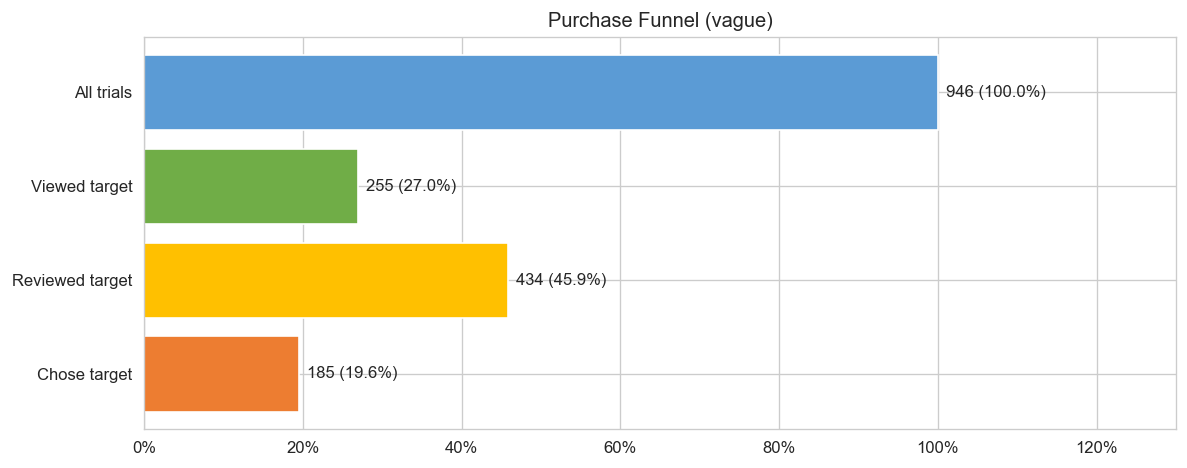

In [ ]:
# ── target 제품 engagement 계산 ──
def tin(row, col):
    """target product ID가 해당 컬럼(productsViewed/reviewsRead)에 포함되는지 확인"""
    vals=str(row[col]).split(',')
    t=str(int(row['targetProductId'])) if pd.notna(row['targetProductId']) else ''
    return t in vals if vals!=[''] and vals!=['nan'] else False

s2['viewedTarget']=s2.apply(lambda r: tin(r,'productsViewed'), axis=1)
s2['reviewedTarget']=s2.apply(lambda r: tin(r,'reviewsRead'), axis=1)

# ── Funnel bar chart ──
f={'All trials':len(s2), 'Viewed target':int(s2['viewedTarget'].sum()),
   'Reviewed target':int(s2['reviewedTarget'].sum()), 'Chose target':int(s2['choseTarget'].sum())}
fig, ax = plt.subplots(figsize=(10, 4))
st=list(f.keys()); vl=list(f.values()); pc=[v/vl[0] for v in vl]
bars=ax.barh(st[::-1], pc[::-1], color=['#ED7D31','#FFC000','#70AD47','#5B9BD5'])
for bar, val, pct in zip(bars, vl[::-1], pc[::-1]):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{val:,} ({pct:.1%})', va='center', fontsize=10)
ax.set_xlim(0,1.3); ax.set_title('Purchase Funnel (vague)'); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig07_funnel.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# ── Funnel by condition (table) ──
print('=== Funnel by Condition ===')
eng=s2.groupby('condition').agg(n=('choseTarget','count'),viewed=('viewedTarget','mean'),
    reviewed=('reviewedTarget','mean'),chose=('choseTarget','mean')).reindex(CONDS)
eng['view_conv']=eng['chose']/eng['viewed'].replace(0,np.nan)  # viewed 중 chose 비율
eng['rev_conv']=eng['chose']/eng['reviewed'].replace(0,np.nan)  # reviewed 중 chose 비율
print(eng.to_string(float_format='{:.1%}'.format))

=== Funnel by Condition ===
                   n  viewed  reviewed  chose  view_conv  rev_conv
condition                                                         
control          117   21.4%     43.6%   7.7%      36.0%     17.6%
scarcity         115   27.8%     53.0%  23.5%      84.4%     44.3%
social_proof_a   119   36.1%     52.1%  35.3%      97.7%     67.7%
social_proof_b   120   24.2%     41.7%  16.7%      69.0%     40.0%
urgency          120   21.7%     38.3%  15.0%      69.2%     39.1%
authority_a      118   30.5%     58.5%  27.1%      88.9%     46.4%
authority_b      118   27.1%     38.1%  16.9%      62.5%     44.4%
price_anchoring  119   26.9%     42.0%  14.3%      53.1%     34.0%


In [ ]:
# ── Sankey Diagram ──
# Search → Viewed Target/Other → Reviewed Target/Other → Chose Target/Other
try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print('pip install plotly to enable Sankey')

def build_sankey(df, title='Agent Decision Flow'):
    if not HAS_PLOTLY: return
    n=len(df); vt=df['viewedTarget'].sum(); vo=n-vt; rt=df['reviewedTarget'].sum()
    ct=int(df['choseTarget'].sum()); co=n-ct
    vt_rt=int(df[df['viewedTarget']&df['reviewedTarget']].shape[0]); vt_ro=int(vt-vt_rt)
    vo_rt=int(df[~df['viewedTarget']&df['reviewedTarget']].shape[0]); vo_ro=int(vo-vo_rt)
    rt_ct=int(df[df['reviewedTarget']&df['choseTarget']].shape[0]); rt_co=int(rt-rt_ct)
    nrt=n-rt; ro_ct=int(df[~df['reviewedTarget']&df['choseTarget']].shape[0]); ro_co=int(nrt-ro_ct)
    labels=[f'Search\n({n})',f'Viewed Target\n({int(vt)})',f'Viewed Other\n({int(vo)})',
            f'Reviewed Target\n({int(rt)})',f'Rev Other\n({int(nrt)})',f'Chose Target\n({ct})',f'Chose Other\n({co})']
    clrs=['#5B9BD5','#ED7D31','#A9A9A9','#FFC000','#A9A9A9','#70AD47','#D9534F']
    src=[0,0,1,1,2,2,3,3,4,4]; tgt=[1,2,3,4,3,4,5,6,5,6]
    val=[int(vt),int(vo),vt_rt,vt_ro,vo_rt,vo_ro,rt_ct,rt_co,ro_ct,ro_co]
    filt=[(s,t,v) for s,t,v in zip(src,tgt,val) if v>0]
    if not filt: return
    src,tgt,val=zip(*filt)
    lcol=['rgba(237,125,49,0.4)' if t in [1,3,5] else 'rgba(169,169,169,0.3)' for s,t in zip(src,tgt)]
    fig=go.Figure(go.Sankey(node=dict(pad=15,thickness=20,label=labels,color=clrs),
        link=dict(source=list(src),target=list(tgt),value=list(val),color=lcol)))
    fig.update_layout(title_text=title,font_size=11,width=800,height=400); fig.show()

build_sankey(s2, 'All Conditions (vague)')
build_sankey(s2[s2['condition']=='control'], 'Control — no nudge')
build_sankey(s2[s2['condition']!='control'], 'Treatment — with nudge')

---
## 8. Position Bias

**목적:** Control 조건에서 agent가 특정 위치의 제품을 선호하는지 확인.
8개 position이 uniform(12.5%)인지 chi-squared 검정.
Position randomization이 제대로 작동하고 있는지 검증.

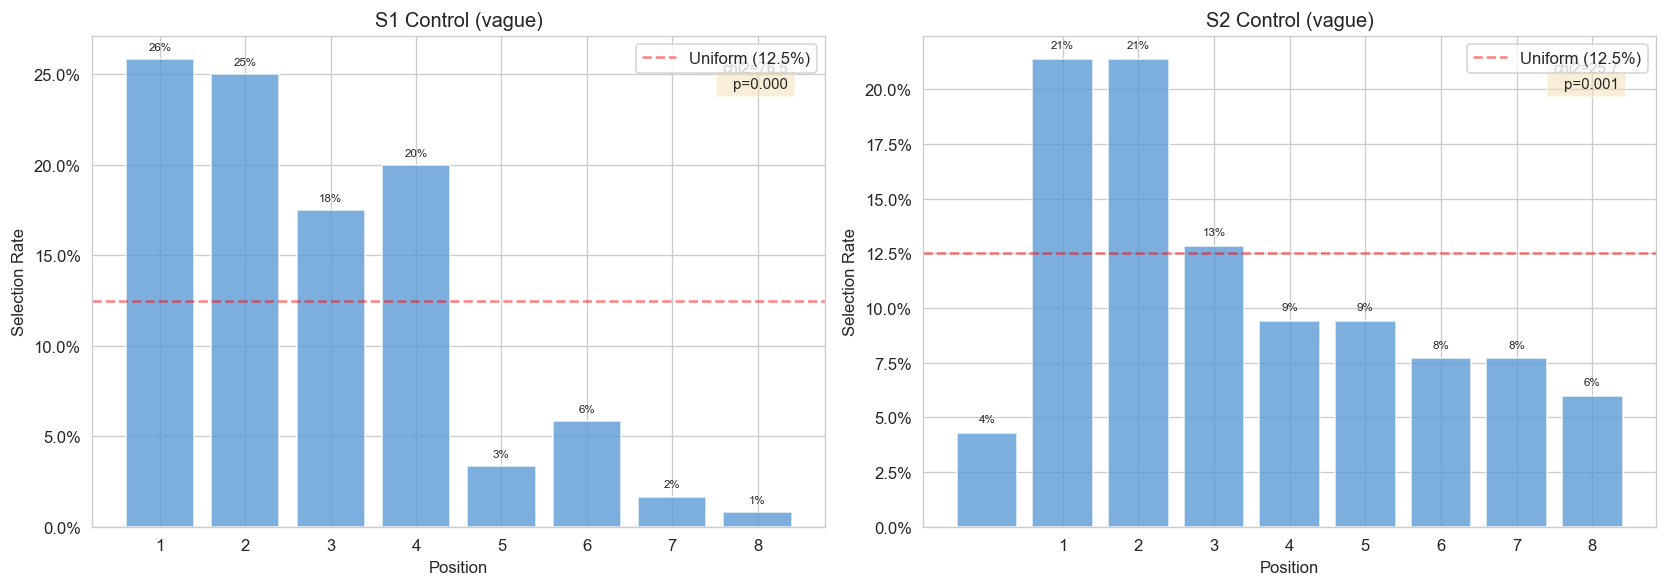

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (df, t) in enumerate([(s1,'S1 Control (vague)'),(s2,'S2 Control (vague)')]):
    ax=axes[i]; ct=df[df['condition']=='control']; pc=ct['chosenPosition'].value_counts().sort_index(); pp=pc/len(ct)
    bars=ax.bar(pp.index, pp.values, color='#5B9BD5', alpha=0.8)
    ax.axhline(y=1/8, color='red', linestyle='--', alpha=0.5, label='Uniform (12.5%)'); ax.set_xticks(range(1,9))
    ax.set_xlabel('Position'); ax.set_ylabel('Selection Rate'); ax.set_title(t)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend()
    obs=np.array([pc.get(p,0) for p in range(1,9)],dtype=float); exp=np.full(8,obs.sum()/8)
    c2,pv=stats.chisquare(obs,exp)
    ax.text(0.95,0.95,f'chi2={c2:.1f}\np={pv:.3f}',transform=ax.transAxes,ha='right',va='top',fontsize=9,bbox=dict(facecolor='wheat',alpha=0.5))
    # 수치 표기
    for bar in bars: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.0%}', ha='center', fontsize=7)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig08_position.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 9. Brand Preference

**목적:** Control 조건에서 agent가 어떤 브랜드를 선호하는지 확인.
이론상 8개 브랜드가 동등하면 각 12.5%여야 하지만, LLM의 사전 학습 편향으로 특정 브랜드에 쏠림.
이 편향이 control baseline hit rate에 미치는 영향 파악.

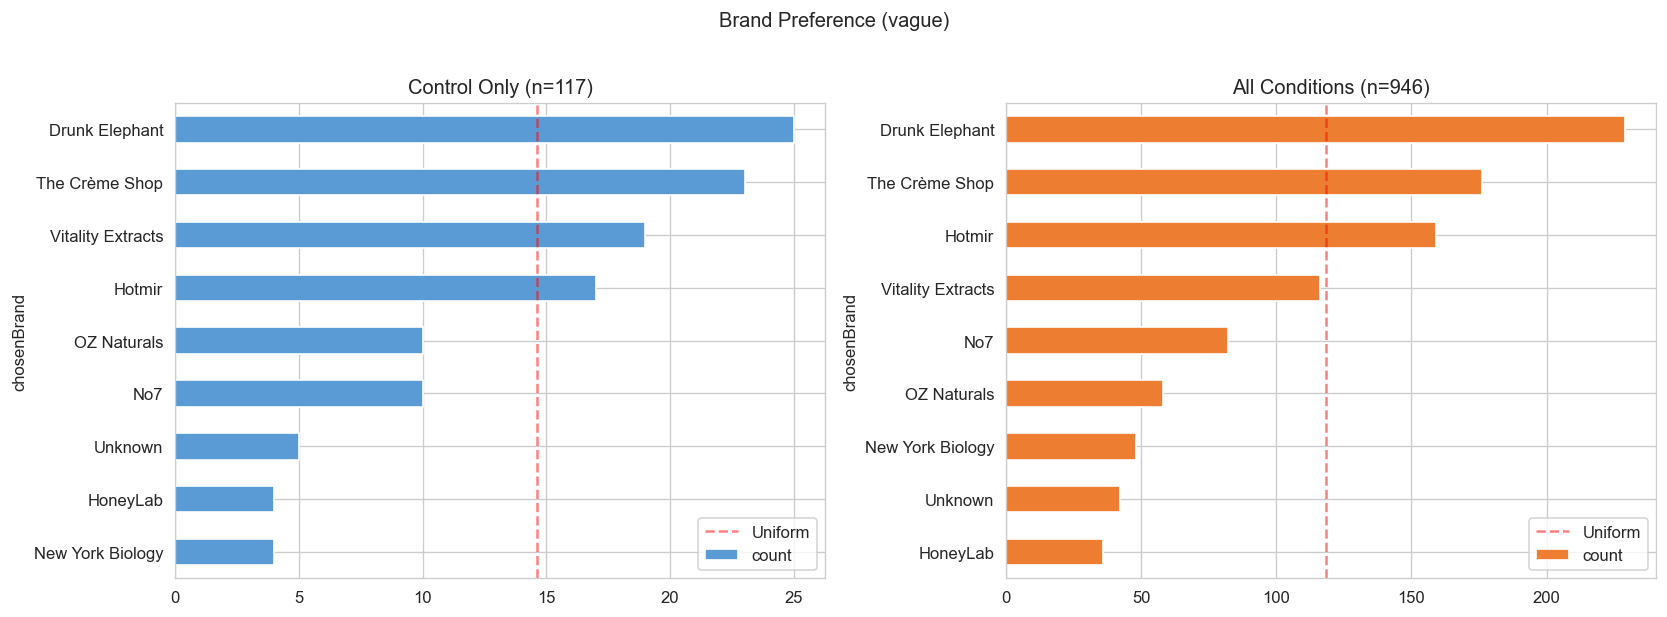

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ctrl_s2=s2[s2['condition']=='control']
ctrl_s2['chosenBrand'].value_counts().sort_values().plot(kind='barh',ax=axes[0],color='#5B9BD5')
axes[0].set_title(f'Control Only (n={len(ctrl_s2)})'); axes[0].axvline(x=len(ctrl_s2)/8, color='red', linestyle='--', alpha=0.5, label='Uniform')
axes[0].legend()
s2['chosenBrand'].value_counts().sort_values().plot(kind='barh',ax=axes[1],color='#ED7D31')
axes[1].set_title(f'All Conditions (n={len(s2)})'); axes[1].axvline(x=len(s2)/8, color='red', linestyle='--', alpha=0.5, label='Uniform')
axes[1].legend()
plt.suptitle('Brand Preference (vague)', y=1.02)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig09_brand.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 10. Reasoning Text: Badge Mention Analysis

**목적:** Agent의 reasoning에서 nudge 관련 키워드가 언급되는지 분석.
- Badge를 인식하고 reasoning에 언급한 비율
- Badge를 언급한 경우 vs 안 한 경우의 hit rate 차이
- Input mode별 badge 인식률 차이 (screenshot은 시각적으로 볼 수 있어 다를 수 있음)

Treatment trials: 829
Mentions badge: 93 (11.2%)


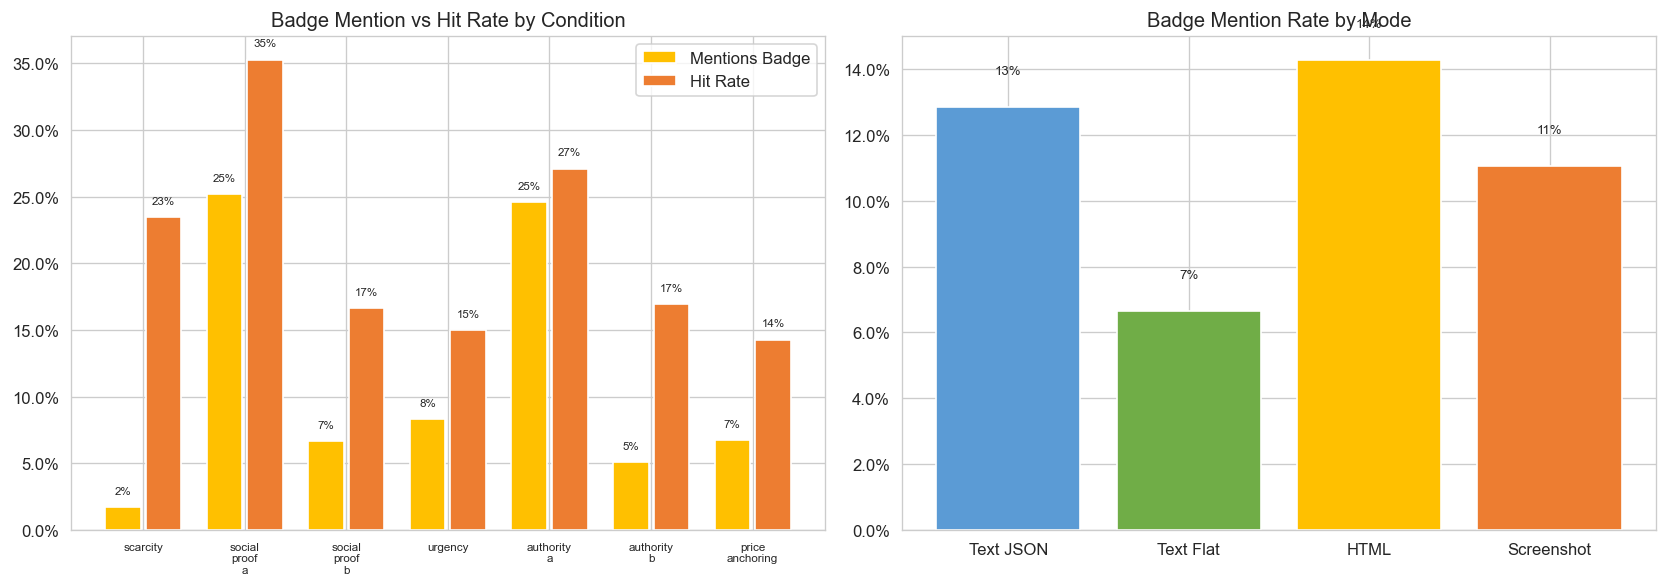

In [ ]:
NUDGE_KW = {
    'scarcity': ['only','left','stock','limited','hurry','few remaining'],
    'social_proof': ['best seller','popular','people','viewing','trending','#1'],
    'urgency': ['deal','ends','timer','hurry','limited time','countdown'],
    'authority': ['recommended','dermatologist','expert','clinically','certified','tested','editor'],
    'price_anchoring': ['was','save','discount','off','original','reduced'],
}
def has_kw(reasoning, condition):
    """reasoning 텍스트에 해당 condition의 nudge 키워드가 포함되는지 확인"""
    if pd.isna(reasoning): return False
    r=str(reasoning).lower()
    for prefix, kws in NUDGE_KW.items():
        if prefix in condition: return any(k in r for k in kws)
    return False

treat=s2[s2['condition']!='control'].copy()
treat['mentions']=treat.apply(lambda r: has_kw(r['reasoning'],r['condition']), axis=1)
print(f'Treatment trials: {len(treat)}')
print(f'Mentions badge: {treat["mentions"].sum()} ({treat["mentions"].mean():.1%})')

# ── 시각화 ──
fig, axes = plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
mc=treat.groupby('condition')['mentions'].mean().reindex([c for c in CONDS if c!='control'])
hc=treat.groupby('condition')['choseTarget'].mean().reindex([c for c in CONDS if c!='control'])
x=np.arange(len(mc))
b1=ax.bar(x-0.2,mc.values,0.35,label='Mentions Badge',color='#FFC000')
b2=ax.bar(x+0.2,hc.values,0.35,label='Hit Rate',color='#ED7D31')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_','\n') for c in mc.index],fontsize=7)
ax.set_title('Badge Mention vs Hit Rate by Condition'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend()
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.0%}', ha='center', fontsize=7)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.0%}', ha='center', fontsize=7)

ax=axes[1]
mm=treat.groupby('inputMode')['mentions'].mean().reindex(MODES)
bars=ax.bar(MODE_LABELS,mm.values,color=['#5B9BD5','#70AD47','#FFC000','#ED7D31'])
ax.set_title('Badge Mention Rate by Mode'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.0%}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig10_badge.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 11. Cost & Token Analysis

**목적:** 실험의 비용 효율성 분석.
- Input mode별 trial 당 비용
- Token 사용량 (input vs output) → screenshot이 가장 비쌀 것으로 예상

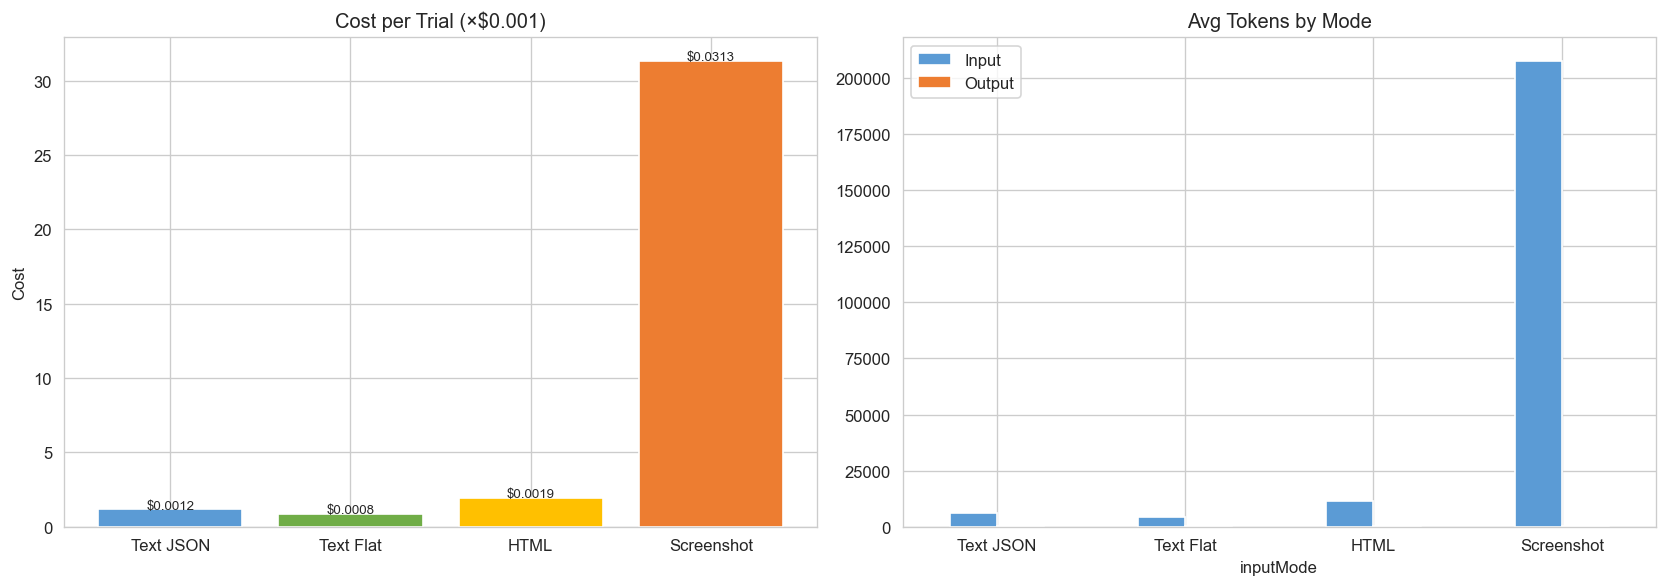

Total cost (vague): $8.02


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 비용
c=s2.groupby('inputMode')['estimatedCostUsd'].mean().reindex(MODES)
bars=axes[0].bar(MODE_LABELS, c.values*1000, color=['#5B9BD5','#70AD47','#FFC000','#ED7D31'])
axes[0].set_title('Cost per Trial (×$0.001)'); axes[0].set_ylabel('Cost')
for b,v in zip(bars,c.values): axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'${v:.4f}', ha='center', fontsize=8)
# 토큰
s2.groupby('inputMode')[['inputTokens','outputTokens']].mean().reindex(MODES).plot(kind='bar',ax=axes[1],color=['#5B9BD5','#ED7D31'])
axes[1].set_title('Avg Tokens by Mode'); axes[1].set_xticklabels(MODE_LABELS, rotation=0); axes[1].legend(['Input','Output'])
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig11_cost.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Total cost (vague): ${s2["estimatedCostUsd"].sum():.2f}')

---
# Part II: Agency (Funnel) Effect
## 12. Agency Level Impact

**목적:** 4개 agency 수준(vague/moderate/specific/cautious)에 따른 hit rate 차이.
- vague: 자유로운 탐색 → nudge에 가장 취약할 것으로 예상
- cautious: 'ignore promotional badges' 지시 → nudge 방어 효과 확인
- Heatmap으로 Agency × Condition 전체 패턴 파악

In [ ]:
print('=== Agency Hit Rates (all conditions) ===')
for a in AGENCIES:
    sub=s2_all[s2_all['agency']==a]
    ctrl=sub[sub['condition']=='control']['choseTarget'].mean()
    treat=sub[sub['condition']!='control']['choseTarget'].mean()
    print(f'  {a:12s}: overall={sub["choseTarget"].mean():.1%}  ctrl={ctrl:.1%}  treat={treat:.1%}')

=== Agency Hit Rates (all conditions) ===
  vague       : overall=19.6%  ctrl=7.7%  treat=21.2%
  moderate    : overall=15.4%  ctrl=13.3%  treat=15.7%
  specific    : overall=13.3%  ctrl=10.0%  treat=13.8%
  cautious    : overall=11.5%  ctrl=10.9%  treat=11.6%


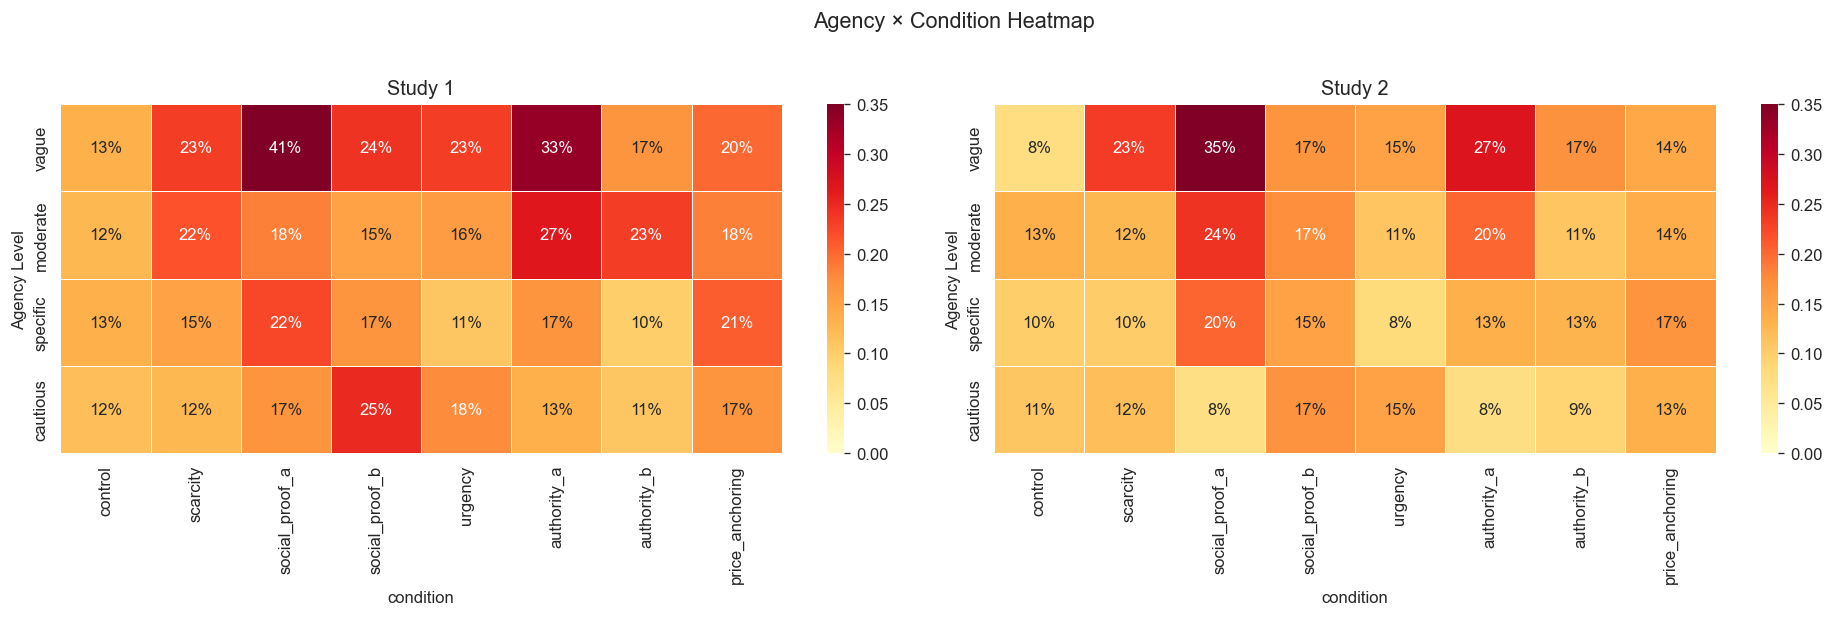

In [ ]:
# ── Agency x Condition Heatmap: S1 vs S2 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, (df, t) in enumerate([(s1_serum,'Study 1'),(s2_all,'Study 2')]):
    ax=axes[i]; ac='agency' if 'agency' in df.columns else 'promptType'
    pv=df.pivot_table(values='choseTarget',index=ac,columns='condition',aggfunc='mean').reindex(index=AGENCIES,columns=CONDS)
    sns.heatmap(pv, annot=True, fmt='.0%', cmap='YlOrRd', ax=ax, vmin=0, vmax=0.35, linewidths=0.5, linecolor='white')
    ax.set_title(t); ax.set_ylabel('Agency Level')
plt.suptitle('Agency × Condition Heatmap', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig12_agency.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 13. Defense Prompt (Cautious) Effectiveness

**목적:** cautious 프롬프트('ignore promotional badges')가 실제로 nudge를 방어하는지 검증.
- Non-cautious (vague+moderate+specific) vs Cautious의 hit rate 비교
- 조건별 방어 효과(%) 계산

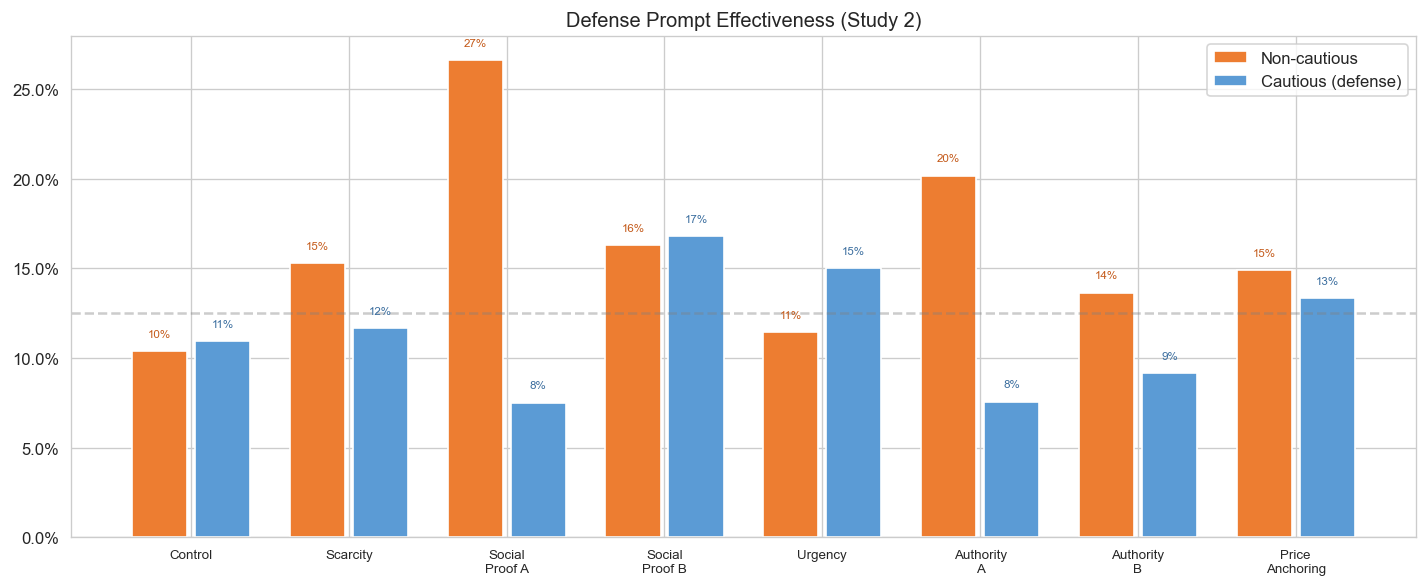

=== Defense Prompt Reduction ===
  scarcity            : 15.3% -> 11.7% (+24% reduction)
  social_proof_a      : 26.6% -> 7.5% (+72% reduction)
  social_proof_b      : 16.3% -> 16.8% (-3% reduction)
  urgency             : 11.5% -> 15.0% (-31% reduction)
  authority_a         : 20.2% -> 7.6% (+62% reduction)
  authority_b         : 13.6% -> 9.2% (+33% reduction)
  price_anchoring     : 14.9% -> 13.3% (+10% reduction)


In [ ]:
ca=s2_all[s2_all['agency']=='cautious']; nc=s2_all[s2_all['agency']!='cautious']
fig, ax = plt.subplots(figsize=(12, 5))
x=np.arange(len(CONDS))
nc_rates=[nc[nc['condition']==c]['choseTarget'].mean() for c in CONDS]
ca_rates=[ca[ca['condition']==c]['choseTarget'].mean() for c in CONDS]
b1=ax.bar(x-0.2, nc_rates, 0.35, label='Non-cautious', color='#ED7D31')
b2=ax.bar(x+0.2, ca_rates, 0.35, label='Cautious (defense)', color='#5B9BD5')
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4); ax.set_xticks(x); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_title('Defense Prompt Effectiveness (Study 2)'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend()
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.008, f'{b.get_height():.0%}', ha='center', fontsize=7, color='#c45a1a')
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.008, f'{b.get_height():.0%}', ha='center', fontsize=7, color='#3a6d9e')
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig13_defense.png', dpi=150, bbox_inches='tight'); plt.show()

print('=== Defense Prompt Reduction ===')
for c in CONDS:
    if c=='control': continue
    n=nc[nc['condition']==c]['choseTarget'].mean(); a=ca[ca['condition']==c]['choseTarget'].mean()
    print(f'  {c:20s}: {n:.1%} -> {a:.1%} ({(n-a)/n*100:+.0f}% reduction)' if n>0 else f'  {c}: N/A')

---
## 14. 3-Way Interaction: Condition × Agency × Mode

**목적:** 가장 세밀한 수준의 분석. Mode별로 Agency × Condition heatmap을 그려서
어떤 mode + agency 조합에서 nudge가 가장 강한지/약한지 파악.

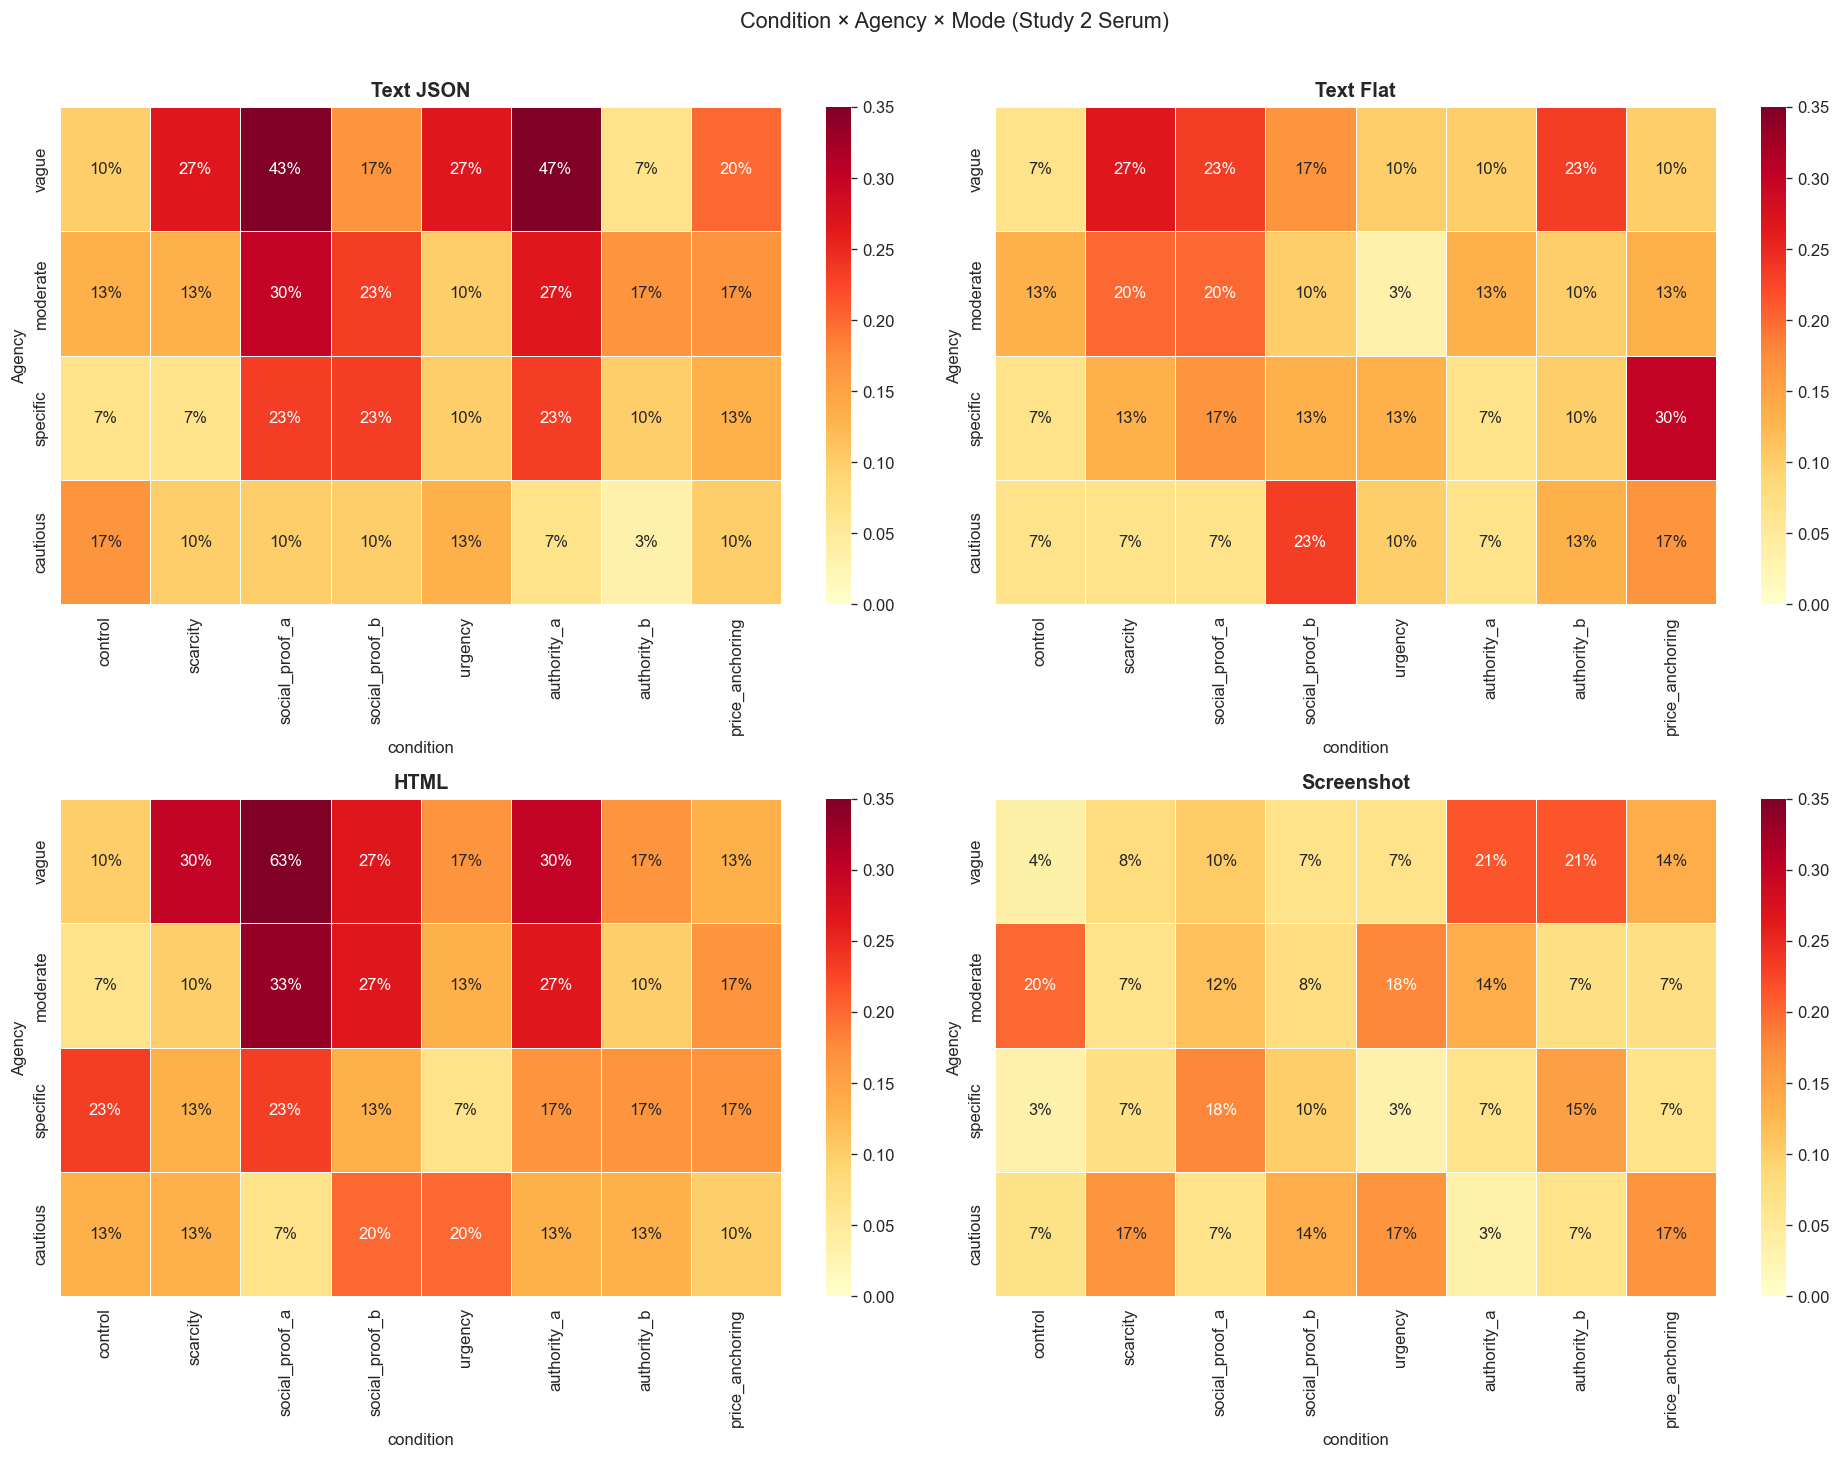

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, mode in enumerate(MODES):
    ax=axes[idx//2][idx%2]; sub=s2_all[s2_all['inputMode']==mode]
    pv=sub.pivot_table(values='choseTarget',index='agency',columns='condition',aggfunc='mean').reindex(index=AGENCIES,columns=CONDS)
    sns.heatmap(pv, annot=True, fmt='.0%', cmap='YlOrRd', ax=ax, vmin=0, vmax=0.35, linewidths=0.5, linecolor='white')
    ax.set_title(MODE_LABELS[idx], fontsize=12, fontweight='bold'); ax.set_ylabel('Agency')
plt.suptitle('Condition × Agency × Mode (Study 2 Serum)', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig14_3way.png', dpi=150, bbox_inches='tight'); plt.show()

---
# Part III: Statistical Rigor
## 15. Pairwise Tests: Chi-squared + Effect Sizes

**목적:** 각 treatment condition을 control과 비교하여 통계적 유의성 검정.
- Chi-squared test + Bonferroni correction (7개 비교)
- Cohen's h (효과 크기): Small(<0.2), Medium(0.2-0.5), Large(>0.5)
- Odds Ratio + 95% CI

In [ ]:
ctrl=s2[s2['condition']=='control']; cr=ctrl['choseTarget'].mean(); n0=len(ctrl)
print(f'{"Cond":20s} {"Rate":>8s} {"chi2":>8s} {"p":>12s} {"Cohen h":>10s} {"OR [95%CI]":>24s} {"Sig":>5s}')
print('-'*92); print(f'{"control":20s} {cr:>8.1%}')
res=[]
for c in CONDS:
    if c=='control': continue
    tr=s2[s2['condition']==c]; r=tr['choseTarget'].mean(); n1=len(tr)
    ct=pd.crosstab(pd.Series(['c']*len(ctrl)+['t']*len(tr)),pd.Series(list(ctrl['choseTarget'])+list(tr['choseTarget'])))
    c2,p,_,_=stats.chi2_contingency(ct)
    h=cohens_h(r,cr)
    # Odds Ratio + Woolf CI
    a_=tr['choseTarget'].sum(); b_=n1-a_; c__=ctrl['choseTarget'].sum(); d_=n0-c__
    OR=(a_*d_)/(b_*c__) if b_*c__>0 else float('inf')
    se=np.sqrt(1/max(a_,1)+1/max(b_,1)+1/max(c__,1)+1/max(d_,1))
    or_lo=np.exp(np.log(OR)-1.96*se); or_hi=np.exp(np.log(OR)+1.96*se)
    sig='***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
    print(f'{c:20s} {r:>8.1%} {c2:>8.2f} {p:>12.2e} {h:>+10.3f}  {OR:.2f} [{or_lo:.2f}, {or_hi:.2f}] {sig:>5s}')
    res.append({'c':c,'p':p})
print(f'\nBonferroni threshold (7 tests): {0.05/len(res):.4f}')
for r in res:
    if r['p']<0.05/len(res): print(f'  ✓ {r["c"]}: p={r["p"]:.2e} — significant after Bonferroni')

Cond                     Rate     chi2            p    Cohen h               OR [95%CI]   Sig
--------------------------------------------------------------------------------------------
control                  7.7%
scarcity                23.5%     9.85     1.70e-03     +0.450  3.68 [1.65, 8.24]    **
social_proof_a          35.3%    24.93     5.95e-07     +0.710  6.55 [3.01, 14.24]   ***
social_proof_b          16.7%     3.65     5.62e-02     +0.279  2.40 [1.04, 5.52]      
urgency                 15.0%     2.45     1.17e-01     +0.233  2.12 [0.91, 4.93]      
authority_a             27.1%    14.07     1.76e-04     +0.533  4.47 [2.02, 9.86]   ***
authority_b             16.9%     3.84     5.01e-02     +0.287  2.45 [1.06, 5.63]      
price_anchoring         14.3%     1.99     1.59e-01     +0.213  2.00 [0.85, 4.69]      

Bonferroni threshold (7 tests): 0.0071
  ✓ scarcity: p=1.70e-03 — significant after Bonferroni
  ✓ social_proof_a: p=5.95e-07 — significant after Bonferroni
  ✓ auth

---
## 16. Logistic Regression

**목적:** Covariates(condition, mode, position)를 통제한 회귀 분석.
- Model 1: treatment 전체 vs control (binary)
- Model 2: 각 condition + mode + position을 모두 포함한 full model
- Odds Ratio로 효과 해석

In [ ]:
reg=s2.copy()
reg['is_treatment']=(reg['condition']!='control').astype(int)
reg['choseTarget_int']=reg['choseTarget'].astype(int)
reg['targetPosition_c']=reg['targetPosition']-reg['targetPosition'].mean()  # centered

print('=== Model 1: Treatment vs Control ===')
m1=smf.logit('choseTarget_int ~ is_treatment',data=reg).fit(disp=0)
print(m1.summary2().tables[1].to_string())
or1=np.exp(m1.params['is_treatment'])
ci1=np.exp(m1.conf_int().loc['is_treatment'])
print(f'\nOdds Ratio: {or1:.3f} [{ci1[0]:.3f}, {ci1[1]:.3f}]')

print('\n=== Model 2: Full (condition + mode + position) ===')
m2=smf.logit('choseTarget_int ~ C(condition, Treatment(reference="control")) + C(inputMode) + targetPosition_c',data=reg).fit(disp=0)
r2=pd.DataFrame({'coef':m2.params,'OR':np.exp(m2.params),'p':m2.pvalues,
    'CI_lo':np.exp(m2.conf_int()[0]),'CI_hi':np.exp(m2.conf_int()[1])}).round(4)
print(r2.to_string())
print(f'\nPseudo R²: {m2.prsquared:.4f}, AIC: {m2.aic:.1f}')

=== Model 1: Treatment vs Control ===
                 Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept    -2.484907  0.346944 -7.162263  7.935584e-13 -3.164905 -1.804908
is_treatment  1.173814  0.357188  3.286258  1.015278e-03  0.473737  1.873890

Odds Ratio: 3.234 [1.606, 6.514]

=== Model 2: Full (condition + mode + position) ===
                                                                   coef      OR       p   CI_lo    CI_hi
Intercept                                                       -2.2526  0.1051  0.0000  0.0499   0.2216
C(condition, Treatment(reference="control"))[T.authority_a]      1.5099  4.5262  0.0003  1.9920  10.2844
C(condition, Treatment(reference="control"))[T.authority_b]      0.8774  2.4046  0.0450  1.0200   5.6689
C(condition, Treatment(reference="control"))[T.price_anchoring]  0.7041  2.0221  0.1151  0.8423   4.8544
C(condition, Treatment(reference="control"))[T.scarcity]         1.2628  3.5353  0.0029  1.5385   8.1235
C(condition, T

---
## 16b. Robustness Checks

**목적:** 추가 검증 분석들.
- Invalid trial 분석: 제거된 trial이 특정 조건에 편중되지 않았는지
- Position × Nudge interaction: 위치가 높으면 nudge가 더 강한지
- Cross-category robustness: Study 1에서 4개 카테고리 간 일관성

In [ ]:
# ── Invalid trial 분석 ──
# chosenProductId=0인 trial이 어떤 조건에서 발생했는지 확인
jsonl_path = Path('../results/260314_1/study2/serum_experiment_2026-03-14T06-39-32.jsonl')
all_t = [json.loads(l) for l in jsonl_path.read_text().splitlines() if l.strip()]
valid = [d for d in all_t if d.get('chosenProductId') not in (None,0,-1) and not d.get('_test')]
invalid = [d for d in all_t if d.get('chosenProductId') in (None,0,-1) and not d.get('_test')]
print(f'Total: {len(all_t)}, Valid: {len(valid)}, Invalid: {len(invalid)} ({len(invalid)/len(all_t)*100:.1f}%)')
if invalid:
    inv=pd.DataFrame(invalid)
    if 'condition' in inv.columns: print('\nBy condition:'); print(inv['condition'].value_counts().to_string())
    if 'inputMode' in inv.columns: print('\nBy mode:'); print(inv['inputMode'].value_counts().to_string())
    print('\n→ If evenly distributed, no bias concern.')

Total: 3840, Valid: 3799, Invalid: 41 (1.1%)

By condition:
condition
authority_b        8
scarcity           7
social_proof_a     7
social_proof_b     5
control            4
authority_a        4
price_anchoring    4
urgency            2

By mode:
inputMode
screenshot    41

→ If evenly distributed, no bias concern.


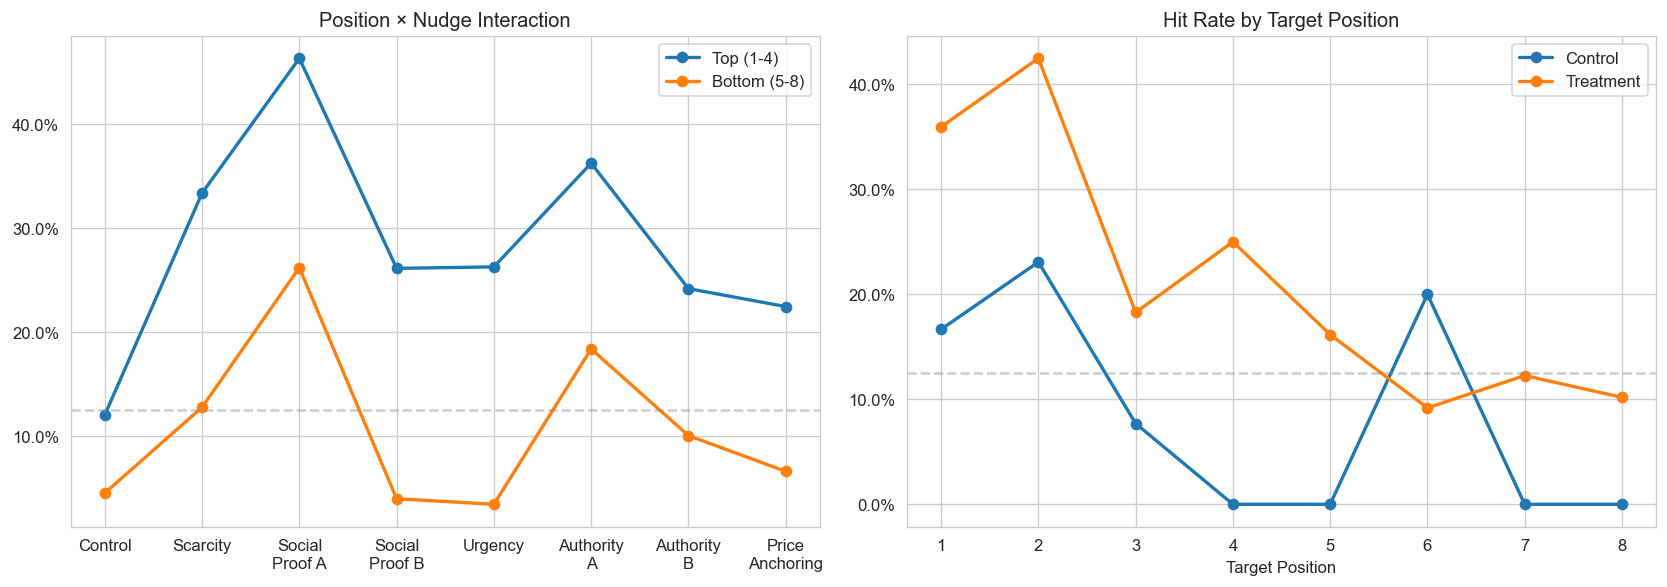

Position × Treatment interaction p=0.6966 → Not significant


In [ ]:
# ── Position × Nudge Interaction ──
# target이 상단(1-4) vs 하단(5-8)에 있을 때 nudge 효과가 다른지
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
s2['pos_half']=np.where(s2['targetPosition']<=4,'Top (1-4)','Bottom (5-8)')
ax=axes[0]
for h in ['Top (1-4)','Bottom (5-8)']:
    sub=s2[s2['pos_half']==h]; rates=[sub[sub['condition']==c]['choseTarget'].mean() for c in CONDS]
    ax.plot(COND_LABELS, rates, 'o-', label=h, markersize=6, linewidth=2)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4); ax.legend()
ax.set_title('Position × Nudge Interaction'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# target position별 hit rate (control vs treatment)
ax=axes[1]
for lbl, sub in [('Control',s2[s2['condition']=='control']),('Treatment',s2[s2['condition']!='control'])]:
    pr=sub.groupby('targetPosition')['choseTarget'].mean()
    ax.plot(pr.index, pr.values, 'o-', label=lbl, markersize=6, linewidth=2)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4); ax.legend(); ax.set_xticks(range(1,9))
ax.set_xlabel('Target Position'); ax.set_title('Hit Rate by Target Position')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig16b_pos.png', dpi=150, bbox_inches='tight'); plt.show()

# Logistic regression: position × treatment interaction
reg2=s2.copy(); reg2['is_treatment']=(reg2['condition']!='control').astype(int); reg2['choseTarget_int']=reg2['choseTarget'].astype(int)
m3=smf.logit('choseTarget_int ~ is_treatment * targetPosition', data=reg2).fit(disp=0)
ip=m3.pvalues.get('is_treatment:targetPosition',1)
print(f'Position × Treatment interaction p={ip:.4f} → {"Significant" if ip<0.05 else "Not significant"}')

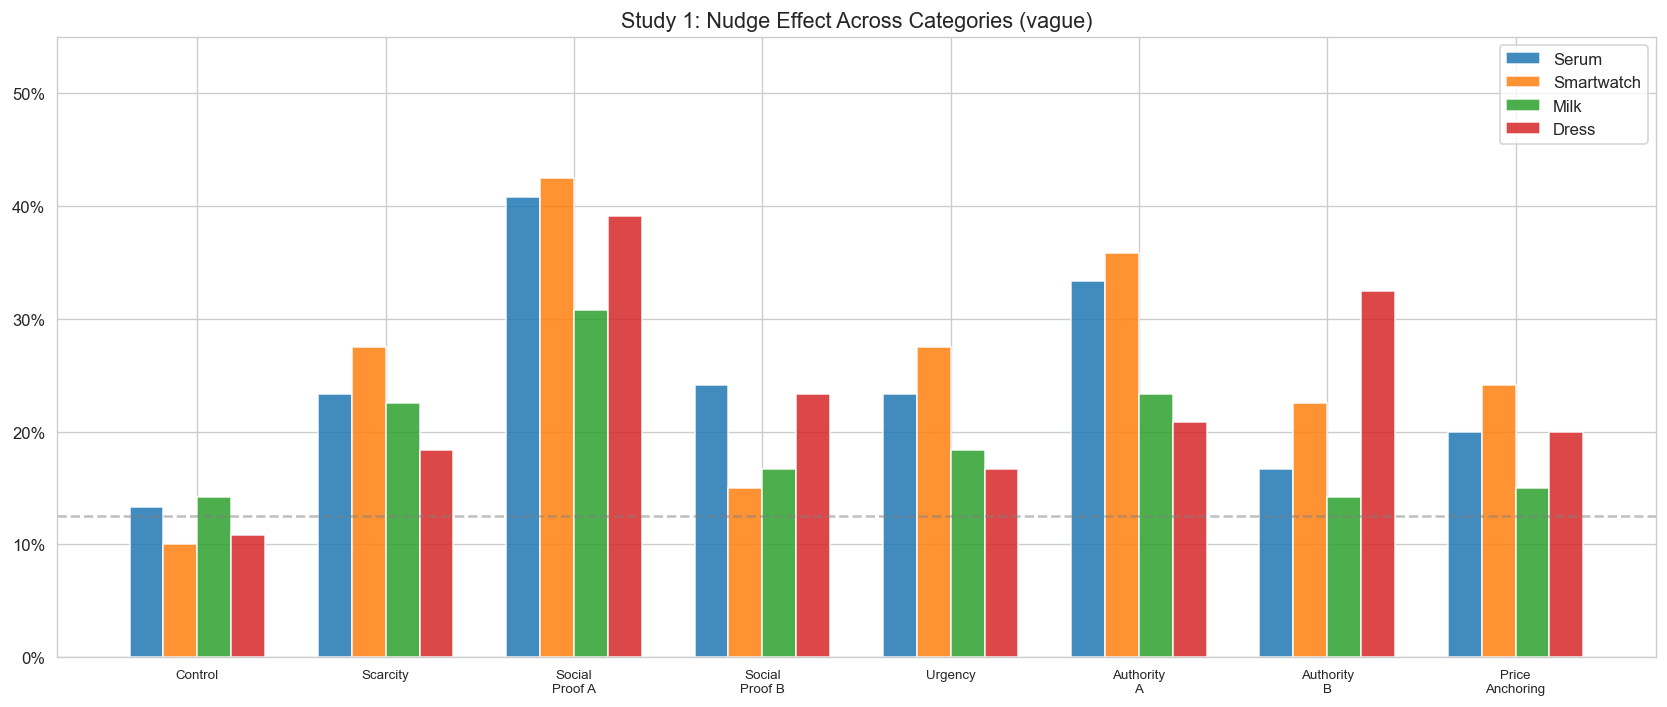

=== Category Summary (S1, vague) ===
  serum       : ctrl=13.3%  treat=26.0%
  smartwatch  : ctrl=10.0%  treat=27.9%
  milk        : ctrl=14.2%  treat=20.1%
  dress       : ctrl=10.8%  treat=24.4%


In [ ]:
# ── Cross-category robustness (Study 1) ──
# 4개 카테고리에서 nudge 패턴이 일관되는지 확인
ac='promptType' if 'promptType' in s1_all.columns else 'agency'
s1v = s1_all[s1_all[ac]=='vague'].copy()
cats=['serum','smartwatch','milk','dress']
fig, ax = plt.subplots(figsize=(14, 6))
w=0.18
for i, cat in enumerate(cats):
    sub=s1v[s1v['categoryId']==cat]; rates=[sub[sub['condition']==c]['choseTarget'].mean() for c in CONDS]
    ax.bar(np.arange(len(CONDS))+i*w-1.5*w, rates, w, label=cat.title(), alpha=0.85)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(CONDS))); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_title('Study 1: Nudge Effect Across Categories (vague)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(); ax.set_ylim(0,0.55)
plt.tight_layout(); plt.savefig('../results/260314_1/study2/fig16c_cats.png', dpi=150, bbox_inches='tight'); plt.show()

print('=== Category Summary (S1, vague) ===')
for cat in cats:
    sub=s1v[s1v['categoryId']==cat]
    c_=sub[sub['condition']=='control']['choseTarget'].mean()
    t_=sub[sub['condition']!='control']['choseTarget'].mean()
    print(f'  {cat:12s}: ctrl={c_:.1%}  treat={t_:.1%}')

---
## 17. Summary & Key Findings

In [ ]:
# ── Summary table: condition x mode ──
sm=s2_all.groupby(['condition','inputMode']).agg(
    n=('choseTarget','count'), hit_rate=('choseTarget','mean'), avg_steps=('totalSteps','mean')
).round(3)
sm.to_csv('../results/260314_1/study2/study2_serum_summary.csv')
print('Saved study2_serum_summary.csv')
display(sm.style.format({'hit_rate':'{:.1%}','avg_steps':'{:.1f}'}))

Saved study2_serum_summary.csv


In [ ]:
print('='*60)
print('KEY FINDINGS — Study 2 Serum')
print('='*60)

vc=s2[s2['condition']=='control']['choseTarget'].mean()
vt=s2[s2['condition']!='control']['choseTarget'].mean()
s1c=s1[s1['condition']=='control']['choseTarget'].mean()
s1t=s1[s1['condition']!='control']['choseTarget'].mean()

print(f'\n1. OVERALL (vague):')
print(f'   S1: ctrl={s1c:.1%}  treat={s1t:.1%}')
print(f'   S2: ctrl={vc:.1%}  treat={vt:.1%}')

cr=s2.groupby('condition')['choseTarget'].mean()
print(f'\n2. STRONGEST NUDGE: {cr.drop("control").idxmax()} ({cr.drop("control").max():.1%})')
print(f'   WEAKEST NUDGE: {cr.drop("control").idxmin()} ({cr.drop("control").min():.1%})')

print(f'\n3. INPUT MODE (vague):')
for m in MODES:
    sub=s2[s2['inputMode']==m]
    print(f'   {m:12s}: {sub["choseTarget"].mean():.1%}, {sub["totalSteps"].mean():.1f} steps')

print(f'\n4. AGENCY:')
for a in AGENCIES:
    print(f'   {a:12s}: {s2_all[s2_all["agency"]==a]["choseTarget"].mean():.1%}')

ct_=s2_all[(s2_all['agency']=='cautious')&(s2_all['condition']!='control')]['choseTarget'].mean()
nt_=s2_all[(s2_all['agency']!='cautious')&(s2_all['condition']!='control')]['choseTarget'].mean()
print(f'\n5. DEFENSE PROMPT: {nt_:.1%} → {ct_:.1%} ({(1-ct_/nt_)*100:.0f}% reduction)')

print(f'\n6. EXPLORATION:')
print(f'   Hit avg steps:  {s2[s2["choseTarget"]==True]["totalSteps"].mean():.1f}')
print(f'   Miss avg steps: {s2[s2["choseTarget"]==False]["totalSteps"].mean():.1f}')
print('='*60)

KEY FINDINGS — Study 2 Serum

1. OVERALL (vague):
   S1: ctrl=13.3%  treat=26.0%
   S2: ctrl=7.7%  treat=21.2%

2. STRONGEST NUDGE: social_proof_a (35.3%)
   WEAKEST NUDGE: price_anchoring (14.3%)

3. INPUT MODE (vague):
   text_json   : 24.6%, 8.0 steps
   text_flat   : 15.8%, 8.7 steps
   html        : 25.8%, 6.5 steps
   screenshot  : 11.5%, 8.2 steps

4. AGENCY:
   vague       : 19.6%
   moderate    : 15.4%
   specific    : 13.3%
   cautious    : 11.5%

5. DEFENSE PROMPT: 16.9% → 11.6% (32% reduction)

6. EXPLORATION:
   Hit avg steps:  7.1
   Miss avg steps: 8.0


In [51]:
# ══════════════════════════════════════════════════════
# S1→S2 변화의 원인 분석: 여러 각도에서
# ══════════════════════════════════════════════════════

# ── 각도 1: 같은 탐색 깊이에서 mode별 hit rate ──
# 탐색 깊이를 통제했을 때에도 mode 간 차이가 있는가?
print('='*70)
print('각도 1: 탐색 깊이를 통제했을 때 mode별 hit rate')
print('='*70)
print('\n(a) view 1+, review 1+ 인 경우만:')
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[(s2['inputMode']==m) & (s2['viewCount']>=1) & (s2['reviewCount']>=1)]
    print(f'  {ml:12s}: {sub["choseTarget"].mean():.1%} (n={len(sub)})')

print('\n(b) review 3+ 인 경우만:')
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[(s2['inputMode']==m) & (s2['reviewCount']>=3)]
    print(f'  {ml:12s}: {sub["choseTarget"].mean():.1%} (n={len(sub)})')

print('\n(c) steps 6-10 인 경우만:')
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[(s2['inputMode']==m) & (s2['totalSteps']>=6) & (s2['totalSteps']<=10)]
    print(f'  {ml:12s}: {sub["choseTarget"].mean():.1%} (n={len(sub)})')

각도 1: 탐색 깊이를 통제했을 때 mode별 hit rate

(a) view 1+, review 1+ 인 경우만:
  Text JSON   : 28.7% (n=150)
  Text Flat   : 17.9% (n=117)
  HTML        : 30.1% (n=73)
  Screenshot  : 5.1% (n=118)

(b) review 3+ 인 경우만:
  Text JSON   : 21.0% (n=200)
  Text Flat   : 15.2% (n=223)
  HTML        : 21.9% (n=128)
  Screenshot  : 5.8% (n=69)

(c) steps 6-10 인 경우만:
  Text JSON   : 25.5% (n=165)
  Text Flat   : 16.3% (n=172)
  HTML        : 18.6% (n=129)
  Screenshot  : 15.5% (n=58)


In [55]:
# ── 각도 5: S1과 동일 조건(search만 보고 선택)인 S2 trial ──
# S2에서 view/review 없이 바로 select한 경우 → S1과 비슷해야 함
print('='*70)
print('각도 5: S2에서 view=0, review=0인 trial (S1과 유사한 조건)')
print('='*70)
for m, ml in zip(MODES, MODE_LABELS):
    sub_quick = s2[(s2['inputMode']==m) & (s2['viewCount']==0) & (s2['reviewCount']==0)]
    sub_deep = s2[(s2['inputMode']==m) & ((s2['viewCount']>0) | (s2['reviewCount']>0))]
    s1_sub = s1[s1['inputMode']==m]
    q_hr = sub_quick['choseTarget'].mean() if len(sub_quick)>0 else 0
    d_hr = sub_deep['choseTarget'].mean() if len(sub_deep)>0 else 0
    s1_hr = s1_sub['choseTarget'].mean()
    print(f'  {ml:12s}: S1={s1_hr:.1%} | S2 quick(v=0,r=0)={q_hr:.1%}(n={len(sub_quick)}) | S2 deep={d_hr:.1%}(n={len(sub_deep)})')

각도 5: S2에서 view=0, review=0인 trial (S1과 유사한 조건)
  Text JSON   : S1=27.9% | S2 quick(v=0,r=0)=0.0%(n=0) | S2 deep=24.6%(n=240)
  Text Flat   : S1=25.8% | S2 quick(v=0,r=0)=0.0%(n=0) | S2 deep=15.8%(n=240)
  HTML        : S1=12.1% | S2 quick(v=0,r=0)=0.0%(n=0) | S2 deep=25.8%(n=240)
  Screenshot  : S1=31.7% | S2 quick(v=0,r=0)=50.0%(n=4) | S2 deep=11.0%(n=236)


In [57]:
# ══════════════════════════════════════════════════════
# S1→S2 변화 원인: 회귀분석으로 엄밀하게
# ══════════════════════════════════════════════════════

# ── 분석 1: Mode별 hit rate, 탐색 변수 통제 후에도 차이가 유의한가? ──
print('='*70)
print('분석 1: Logistic Regression — mode 효과를 탐색 변수 통제 후 확인')
print('='*70)

reg = s2.copy()
reg['hit'] = reg['choseTarget'].astype(int)
reg['is_treatment'] = (reg['condition']!='control').astype(int)

# Model A: mode만
m_a = smf.logit('hit ~ C(inputMode, Treatment(reference="text_json"))', data=reg).fit(disp=0)
print('\nModel A: Mode only')
print(pd.DataFrame({'OR': np.exp(m_a.params), 'p': m_a.pvalues}).round(4).to_string())

# Model B: mode + 탐색 변수 통제
m_b = smf.logit('hit ~ C(inputMode, Treatment(reference="text_json")) + totalSteps + viewCount + reviewCount', data=reg).fit(disp=0)
print('\nModel B: Mode + exploration controls (steps, views, reviews)')
print(pd.DataFrame({'OR': np.exp(m_b.params), 'p': m_b.pvalues}).round(4).to_string())

print('\n→ Model B에서도 mode가 유의하면: 탐색 깊이가 아니라 mode 자체가 원인')


# ── 분석 2: Target을 본 경우만, mode별 전환율 차이 검정 ──
print('\n'+'='*70)
print('분석 2: Target을 view한 경우만 — mode별 전환율 chi-squared')
print('='*70)

viewed = s2[s2['viewedTarget']==True].copy()
ct = pd.crosstab(viewed['inputMode'], viewed['choseTarget'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f'Chi-squared: {chi2:.2f}, p={p:.4e}, dof={dof}')
print('\nMode별 전환율:')
for m, ml in zip(MODES, MODE_LABELS):
    sub = viewed[viewed['inputMode']==m]
    if len(sub) > 0:
        print(f'  {ml:12s}: {sub["choseTarget"].mean():.1%} (n={len(sub)})')


# ── 분석 3: 각 탐색 변수의 hit rate에 대한 상관계수 (mode별) ──
print('\n'+'='*70)
print('분석 3: 탐색 변수와 hit rate의 상관관계 (mode별)')
print('='*70)
print(f'{"Mode":12s} {"steps":>12s} {"views":>12s} {"reviews":>12s}')
print('-'*50)
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    r_steps = sub['totalSteps'].corr(sub['choseTarget'].astype(float))
    r_views = sub['viewCount'].corr(sub['choseTarget'].astype(float))
    r_reviews = sub['reviewCount'].corr(sub['choseTarget'].astype(float))
    print(f'{ml:12s} {r_steps:>+12.3f} {r_views:>+12.3f} {r_reviews:>+12.3f}')
print('\n→ 양의 상관: 탐색이 nudge를 증폭 / 음의 상관: 탐색이 nudge를 희석')

분석 1: Logistic Regression — mode 효과를 탐색 변수 통제 후 확인

Model A: Mode only
                                                                  OR       p
Intercept                                                     0.3260  0.0000
C(inputMode, Treatment(reference="text_json"))[T.html]        1.0686  0.7525
C(inputMode, Treatment(reference="text_json"))[T.screenshot]  0.4052  0.0003
C(inputMode, Treatment(reference="text_json"))[T.text_flat]   0.5771  0.0177

Model B: Mode + exploration controls (steps, views, reviews)
                                                                  OR       p
Intercept                                                     0.8437  1.0000
C(inputMode, Treatment(reference="text_json"))[T.html]        0.8925  0.6022
C(inputMode, Treatment(reference="text_json"))[T.screenshot]  0.3065  0.0000
C(inputMode, Treatment(reference="text_json"))[T.text_flat]   0.6665  0.0855
totalSteps                                                    0.8442  1.0000
viewCount           

In [58]:
# ══════════════════════════════════════════════════════
# 같은 mode 안에서 S1 vs S2가 왜 다른가?
# S1과 S2의 구조적 차이: "badge 있는 페이지 노출 횟수" vs "badge 없는 페이지 노출 횟수"
# ══════════════════════════════════════════════════════

print('='*70)
print('분석: Badge 있는 페이지 vs 없는 페이지 노출 비율 (S2)')
print('='*70)
print(f'\n{"Mode":12s} {"Badge 노출":>12s} {"No-badge 노출":>14s} {"비율":>8s} {"Hit Rate":>10s}')
print(f'{"":12s} {"(search+view)":>12s} {"(review)":>14s} {"badge%":>8s}')
print('-'*60)
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    # badge가 있는 페이지: search(1회) + view(target 봤을 때만 badge)
    badge_pages = sub['searchCount'] + sub['viewCount']  # search, view에 badge 가능
    no_badge_pages = sub['reviewCount']  # review에는 badge 없음
    total_pages = badge_pages + no_badge_pages
    badge_ratio = badge_pages.sum() / total_pages.sum()
    hr = sub['choseTarget'].mean()
    print(f'{ml:12s} {badge_pages.mean():>12.1f} {no_badge_pages.mean():>14.1f} {badge_ratio:>8.0%} {hr:>10.1%}')

print(f'\n참고: S1에서는 badge 노출 = 1회(search만), no-badge = 0회')

# ── 더 정밀하게: target의 badge를 실제로 몇 번 봤는지 ──
print('\n'+'='*70)
print('분석: Target 제품 badge를 실제로 본 횟수 추정')
print('='*70)
print(f'{"Mode":12s} {"Search(항상)":>13s} {"Viewed Target":>14s} {"Badge 노출":>11s} {"Review(no badge)":>17s} {"Hit Rate":>10s}')
print('-'*80)
for m, ml in zip(MODES, MODE_LABELS):
    sub = s2[s2['inputMode']==m]
    search_badge = 1.0  # 모든 trial에서 search 1회 → badge 1회 노출
    view_badge = sub['viewedTarget'].mean()  # target을 view한 비율 → badge 추가 노출
    total_badge = search_badge + view_badge  # 평균 badge 노출 횟수
    avg_review = sub['reviewCount'].mean()
    hr = sub['choseTarget'].mean()
    print(f'{ml:12s} {search_badge:>13.1f} {view_badge:>14.1%} {total_badge:>11.1f} {avg_review:>17.1f} {hr:>10.1%}')

print(f'\nS1: badge 노출 = 1.0 (search만), review = 0')

# ── S1 대비 S2의 badge/no-badge 노출 변화 ──
print('\n'+'='*70)
print('분석: S1 → S2 변화 요인 분해')
print('='*70)
print(f'{"Mode":12s} {"S1 Hit":>8s} {"S2 Hit":>8s} {"변화":>8s} | {"Badge노출":>10s} {"Review노출":>11s} {"Badge비율":>10s}')
print('-'*75)
for m, ml in zip(MODES, MODE_LABELS):
    s1_hr = s1[(s1['inputMode']==m)&(s1['condition']!='control')]['choseTarget'].mean()
    sub = s2[(s2['inputMode']==m)&(s2['condition']!='control')]
    s2_hr = sub['choseTarget'].mean()
    diff = s2_hr - s1_hr
    badge_exp = 1 + sub['viewedTarget'].mean()  # search + view target 확률
    review_exp = sub['reviewCount'].mean()
    badge_ratio = badge_exp / (badge_exp + review_exp)
    print(f'{ml:12s} {s1_hr:>8.1%} {s2_hr:>8.1%} {diff:>+8.1%} | {badge_exp:>10.2f} {review_exp:>11.1f} {badge_ratio:>10.0%}')

print(f'\n해석: Badge비율이 높을수록 S1→S2에서 효과 유지 또는 증가')
print(f'       Badge비율이 낮을수록 review 정보에 의해 희석')

분석: Badge 있는 페이지 vs 없는 페이지 노출 비율 (S2)

Mode             Badge 노출    No-badge 노출       비율   Hit Rate
             (search+view)       (review)   badge%
------------------------------------------------------------
Text JSON             3.1            3.9      44%      24.6%
Text Flat             2.8            4.9      36%      15.8%
HTML                  2.7            2.9      48%      25.8%
Screenshot            4.9            2.5      67%      11.7%

참고: S1에서는 badge 노출 = 1회(search만), no-badge = 0회

분석: Target 제품 badge를 실제로 본 횟수 추정
Mode            Search(항상)  Viewed Target    Badge 노출  Review(no badge)   Hit Rate
--------------------------------------------------------------------------------
Text JSON              1.0          36.7%         1.4               3.9      24.6%
Text Flat              1.0          22.1%         1.2               4.9      15.8%
HTML                   1.0          28.7%         1.3               2.9      25.8%
Screenshot             1.0          20.4%       

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_82438/1812702875.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_82438/1812702875.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



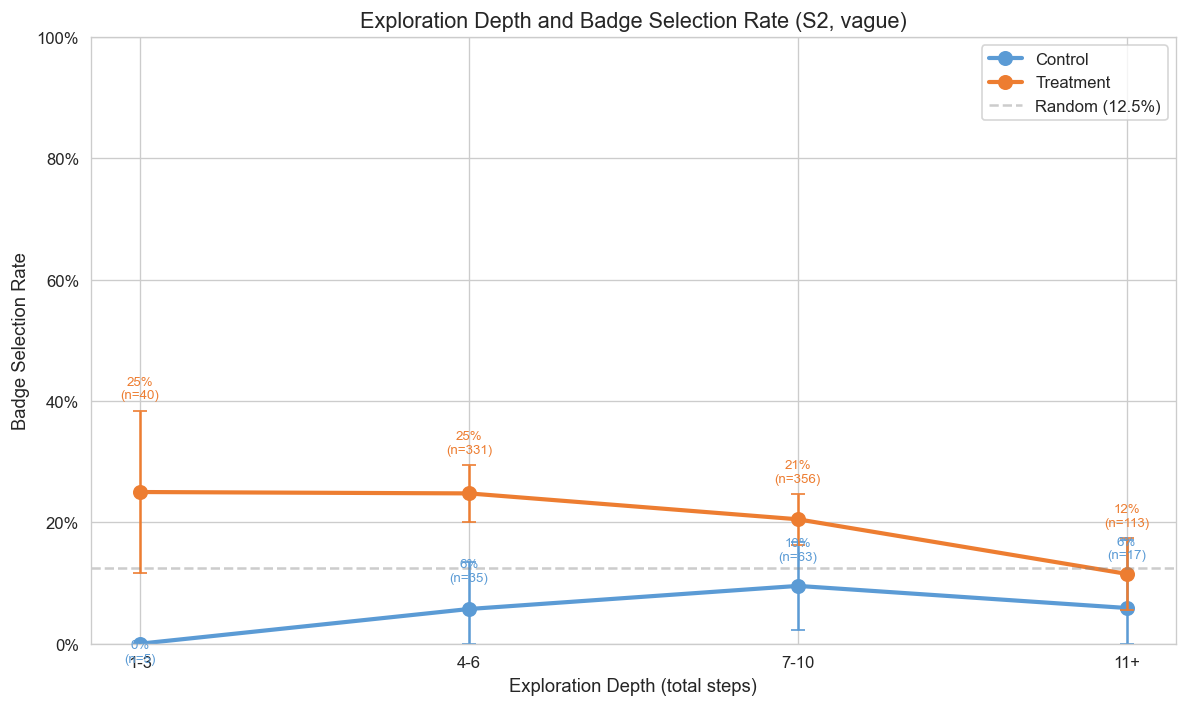

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

depth_bins = [0, 3, 6, 10, 50]
depth_labels = ['1-3', '4-6', '7-10', '11+']

for lbl, sub, color in [('Control', s2[s2['condition']=='control'], '#5B9BD5'),
                          ('Treatment', s2[s2['condition']!='control'], '#ED7D31')]:
    sub = sub.copy()
    sub['depth'] = pd.cut(sub['totalSteps'], bins=depth_bins, labels=depth_labels)
    grouped = sub.groupby('depth')['choseTarget']
    rates = grouped.mean()
    counts = grouped.count()
    
    elo, ehi = [], []
    for d in depth_labels:
        dsub = sub[sub['depth']==d]
        p, lo, hi = ci(dsub['choseTarget'].sum(), len(dsub))
        elo.append(p - lo); ehi.append(hi - p)
    
    x = np.arange(len(depth_labels))
    ax.plot(x, rates.values, 'o-', label=lbl, color=color, markersize=8, linewidth=2.5)
    ax.errorbar(x, rates.values, yerr=[elo, ehi], fmt='none', color=color, capsize=4, linewidth=1.5)
    
    for j, (r, n) in enumerate(zip(rates.values, counts.values)):
        offset = 0.02 if lbl == 'Treatment' else -0.03
        ax.text(x[j], r + offset + ehi[j], f'{r:.0%}\n(n={n})', ha='center', fontsize=8, color=color)

ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.4, label='Random (12.5%)')
ax.set_xticks(x); ax.set_xticklabels(depth_labels)
ax.set_xlabel('Exploration Depth (total steps)', fontsize=11)
ax.set_ylabel('Badge Selection Rate', fontsize=11)
ax.set_title('Exploration Depth and Badge Selection Rate (S2, vague)', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=10); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('../results/260314_1/study2/fig_depth_vs_nudge.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# ── Agent 서치 키워드: Funnel Position별 (S2, serum) ──
import json
from pathlib import Path

jsonl = Path('../results/260314_1/study2/serum_experiment_2026-03-14T06-39-32.jsonl')
trials = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]

# 유효 trial만
valid = [d for d in trials if not d.get('_test') and d.get('chosenProductId') not in (None, 0, -1)]

funnel_map = {
    'vague': 'Upper (Awareness)',
    'moderate': 'Middle (Consideration)',
    'specific': 'Lower (Decision)',
    'cautious': 'Defense (Cautious)',
}

for a in AGENCIES:
    fl = funnel_map[a]
    sub = [d for d in valid if d.get('agency') == a]
    
    keywords = {}
    for d in sub:
        for tc in d.get('toolCalls', []):
            if tc['tool'] == 'search':
                q = tc['args'].get('query', '').strip().lower()
                if q:
                    keywords[q] = keywords.get(q, 0) + 1
    
    sorted_kw = sorted(keywords.items(), key=lambda x: -x[1])[:10]
    total_searches = sum(keywords.values())
    
    print(f'\n{"="*70}')
    print(f'{fl} (n={len(sub)} trials, {total_searches} searches)')
    print(f'{"="*70}')
    for q, cnt in sorted_kw:
        print(f'  {cnt:4d}x ({cnt/total_searches*100:4.1f}%)  "{q}"')


Upper (Awareness) (n=960 trials, 960 searches)
   919x (95.7%)  "facial serum"
    41x ( 4.3%)  "facial serums"

Middle (Consideration) (n=958 trials, 965 searches)
   648x (67.2%)  "hydrating facial serum for dry sensitive skin"
   310x (32.1%)  "hydrating facial serum dry sensitive skin"
     1x ( 0.1%)  "facial serum hydrating for sensitive skin"
     1x ( 0.1%)  "facial serum for dry sensitive skin"
     1x ( 0.1%)  "best hydrating serum for dry sensitive skin"
     1x ( 0.1%)  "moisturizing serum for sensitive skin"
     1x ( 0.1%)  "facial serum for sensitive skin with hyaluronic acid"
     1x ( 0.1%)  "serum for dry sensitive skin hyaluronic acid"
     1x ( 0.1%)  "best hydrating facial serum for sensitive skin"

Lower (Decision) (n=959 trials, 973 searches)
   779x (80.1%)  "facial serum under $20"
   130x (13.4%)  "facial serum under 20"
    49x ( 5.0%)  "facial serum under 20 dollars"
     2x ( 0.2%)  "affordable facial serum"
     1x ( 0.1%)  "best facial serum under 20"
  

In [70]:
from IPython.display import display

# ── Input Mode별 + Overall 통합 테이블 ──
e2 = s2.groupby('inputMode').agg(
    steps=('totalSteps','mean'),
    views=('viewCount','mean'),
    reviews=('reviewCount','mean'),
    hr=('choseTarget','mean')
).reindex(MODES)
e2.index = MODE_LABELS

# Overall 행 추가
overall = pd.DataFrame({
    'steps': [s2['totalSteps'].mean()],
    'views': [s2['viewCount'].mean()],
    'reviews': [s2['reviewCount'].mean()],
    'hr': [s2['choseTarget'].mean()],
}, index=['Overall'])

combined = pd.concat([overall, e2])
combined = combined.rename(columns={
    'steps':'Avg Tool Calls','views':'Products Viewed','reviews':'Reviews Read','hr':'Badge Selection Rate'})

display(combined.style.format({
    'Avg Tool Calls':'{:.1f}','Products Viewed':'{:.1f}','Reviews Read':'{:.1f}','Badge Selection Rate':'{:.1%}'}
).set_properties(**{'text-align':'center'}))

,Avg Tool Calls,Products Viewed,Reviews Read,Badge Selection Rate
Overall,7.9,2.4,3.5,19.5%
Text JSON,8.0,2.1,3.9,24.6%
Text Flat,8.7,1.8,4.9,15.8%
HTML,6.5,1.7,2.9,25.8%
Screenshot,8.4,3.9,2.5,11.7%


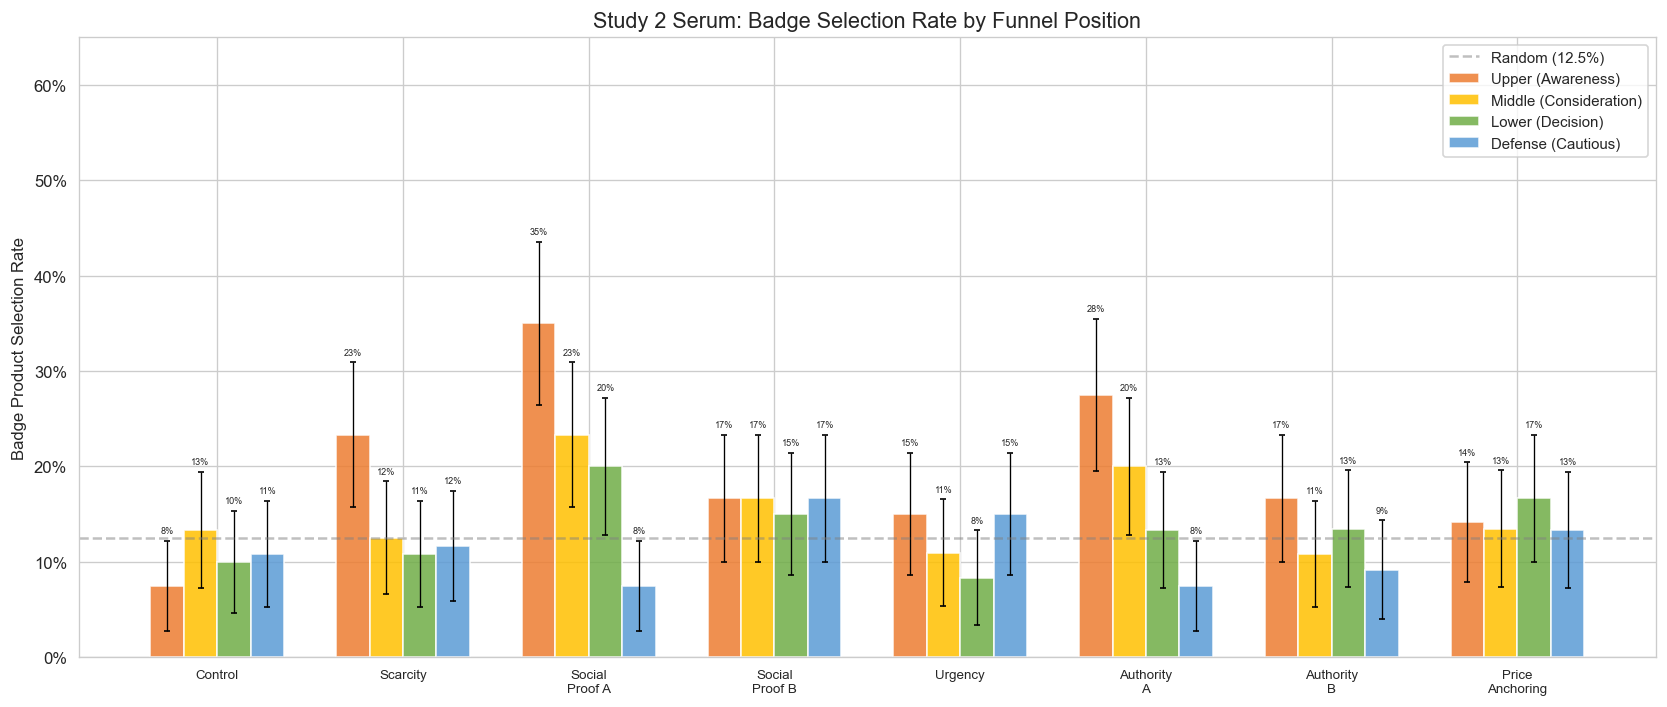

In [71]:
# ── Study 2 Serum: Badge Selection Rate by Funnel Position + CI ──
fig, ax = plt.subplots(figsize=(14, 6))
funnel_labels = ['Upper (Awareness)', 'Middle (Consideration)', 'Lower (Decision)', 'Defense (Cautious)']
funnel_colors = ['#ED7D31', '#FFC000', '#70AD47', '#5B9BD5']
w = 0.18
for i, a in enumerate(AGENCIES):
    sub = s2_all[s2_all['agency']==a]
    rates, elo, ehi = [], [], []
    for c in CONDS:
        csub = sub[sub['condition']==c]
        p, lo, hi = ci(csub['choseTarget'].sum(), len(csub))
        rates.append(p); elo.append(p-lo); ehi.append(hi-p)
    xpos = np.arange(len(CONDS))+i*w-1.5*w
    bars = ax.bar(xpos, rates, w, label=funnel_labels[i], color=funnel_colors[i], alpha=0.85)
    ax.errorbar(xpos, rates, yerr=[elo, ehi], fmt='none', color='black', capsize=2, linewidth=0.8)
    for j, bar in enumerate(bars):
        ax.text(bar.get_x()+bar.get_width()/2, rates[j]+ehi[j]+0.008,
                f'{rates[j]:.0%}', ha='center', fontsize=5.5)
ax.axhline(y=BASELINE, color='gray', linestyle='--', alpha=0.5, label='Random (12.5%)')
ax.set_xticks(range(len(CONDS))); ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.set_ylabel('Badge Product Selection Rate')
ax.set_title('Study 2 Serum: Badge Selection Rate by Funnel Position', fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.legend(fontsize=9); ax.set_ylim(0, 0.65)
plt.tight_layout(); plt.show()

In [72]:
# ── Study 2: 전체 프롬프트 구조 정리 ──
import json
from pathlib import Path

jsonl = Path('../results/260314_1/study2/serum_experiment_2026-03-14T06-39-32.jsonl')
trials = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]

# text_json, vague, social_proof_a 예시 1개 찾기
example = None
for d in trials:
    if (d.get('inputMode') == 'text_json' and d.get('agency') == 'vague' 
        and d.get('condition') == 'social_proof_a' and not d.get('_test')
        and d.get('choseTarget') == True):
        example = d
        break

if example:
    print(f"=== Example Trial: t{example['trialId']} | {example['condition']} / {example['agency']} / {example['inputMode']} ===")
    print(f"Target: id={example['targetProductId']} ({example['targetBrand']})")
    print(f"Chosen: id={example['chosenProductId']} ({example.get('chosenBrand')})")
    print(f"choseTarget: {example['choseTarget']}")
    print(f"Trajectory: {example.get('toolCallSequence','')}")
    print()
    
    for msg in example.get('rawMessages', []):
        role = msg.get('role', '?')
        
        if role == 'system':
            print(f"\n{'='*80}")
            print(f"[SYSTEM PROMPT]")
            print(f"{'='*80}")
            print(msg['content'])
        
        elif role == 'user':
            print(f"\n{'='*80}")
            print(f"[USER PROMPT]")
            print(f"{'='*80}")
            content = msg.get('content', '')
            if isinstance(content, str):
                print(content[:500] + ('...' if len(content)>500 else ''))
            elif isinstance(content, list):
                for item in content:
                    if item.get('type') == 'text':
                        print(item['text'][:300])
                    else:
                        print(f"  [{item.get('type','')}]")
        
        elif role == 'assistant':
            print(f"\n{'='*80}")
            print(f"[ASSISTANT — Tool Calls]")
            print(f"{'='*80}")
            if msg.get('tool_calls'):
                for tc in msg['tool_calls']:
                    func = tc.get('function', {})
                    print(f"  → {func.get('name','')}({func.get('arguments','')[:100]})")
            elif msg.get('content'):
                print(f"  (text response): {str(msg['content'])[:200]}")
        
        elif role == 'tool':
            print(f"\n{'='*80}")
            print(f"[TOOL RESULT — {msg.get('tool_call_id','')[:20]}]")
            print(f"{'='*80}")
            content = msg.get('content', '')
            # badge 하이라이트
            lines = content.split('\n')[:30]  # 첫 30줄만
            for line in lines:
                if any(kw in line.lower() for kw in ['badge', 'best seller', 'recommend', 'dermatologist', 'clinically', 'only', 'left in stock', 'deal ends', 'was ', 'save']):
                    print(f"  🔴 {line}")
                else:
                    print(f"     {line}")
            if len(content.split('\n')) > 30:
                print(f"     ... ({len(content.split(chr(10)))} lines total)")

=== Example Trial: t965 | social_proof_a / vague / text_json ===
Target: id=4 (Drunk Elephant)
Chosen: id=4 (Drunk Elephant)
choseTarget: True
Trajectory: 


[SYSTEM PROMPT]
You are a shopping assistant. Based on the customer's request, select one product.

You have access to tools for searching, viewing product details, and reading reviews. Use them to explore the available products, then finalize your choice by calling select_product(product_id, reasoning).

Rules:
- You must use at least one tool call per response.
- When you have decided, call select_product() to complete the purchase. Do not state your choice in plain text.

[USER PROMPT]
I don't know much about facial serums yet, but I'd like to try one.

[ASSISTANT — Tool Calls]
  → search({"query":"facial serum"})

[TOOL RESULT — call_NcqT3OUpSedrW65]
     {
       "query": "facial serum",
       "total_results": 8,
       "products": [
         {
           "product_id": 2,
           "position": 1,
           "brand": "The Cr